# SABRE with PulsPol

## Imports

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib import ticker, cm 
from matplotlib.colors import Normalize, CenteredNorm

import os
from itertools import product

import spindata
from functools import reduce

import spinSimulations.spin as s
from spinSimulations.solver_H import amplitude, calc_uni, prop_uni, traj_prop_h
from spinSimulations.solver_L import *
from spinSimulations.plotter import *
from scipy.linalg import expm, null_space
from scipy.integrate import solve_ivp

## Spin System setters

In [2]:
# THESE ARE GLOBAL VARS
ss_S = op_S = ppms_S = Js_S = None
ss_C = op_C = ppms_C = Js_C = None
nuc = None

# THIS IS A SETTER FOR THEM
def set_up_spin_system(nuclei='15N'):
    ###################################################
    ### Set up spin system of the free substrate ###
    global ss_S, op_S
    global ppms_S, Js_S
    
    Js_S = np.array(
        [[0]]
    )

    ppms_S = np.array([300])*1e-6

    n_spins = 1

    nuclei_list = [nuclei]

    ss_S = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_S.copy(),
        ppms=ppms_S.copy(),
    )
    
    op_S = ss_S.op

    ###################################################
    ### Set up spin system of the SABRE complex
    global ss_C, op_C
    global ppms_C, Js_C
    global nuc
    #global idx_H, idx_D, idx_X
    
    Js_C = np.array(
            [[0, -7.7, -21],
            [0, 0, 0],
            [0, 0, 0]]
        )

    ppms_C = np.array([-22,-22, 0])*1e-6

    n_spins = 3

    nuclei_list = 2 * ["1H"] + [nuclei]

    ss_C = s.System(
        n_spins, nuclei_list=nuclei_list.copy(),
        is_sparse=False,
        Js=Js_C.copy(),
        ppms=ppms_C.copy(),
    )

    op_C = ss_C.op
    nuc = nuclei
    
T1_S = np.array([20])
T1_C = np.array([6, 6, 20])

set_up_spin_system()

## Helper function

In [3]:
def arg_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

## PP conditions

In [4]:
def pulse_pol_params(J, phi=np.pi/2, n=0, sign='+'):
    if sign == '+':
        tau = (2 * n + 1 + phi / np.pi) / J
    elif sign =='-':
        tau = (2 * n + 1 - phi / np.pi) / J
    else:
        raise ValueError('Sign can only be + or -')
    if tau < 0:
        raise ValueError(f'You got the negative time {tau:.2f}')
    return tau

In [5]:
tau_pp = pulse_pol_params(7.7)
print(f'{tau_pp:.2f}')

0.19


In [6]:
ss_C.nuclei_list

['1H', '1H', '15N']

## Calculations

### SABRE RELATED

In [7]:
#Density matrix of pure pH2
rho_pH2=np.array([
    [0,0,0,0],
    [0,0.5,-0.5,0],
    [0,-0.5,0.5,0],
    [0,0,0,0]
]) 

#Initialization of the composite system matrix
def SABRE_SO(
    ss_S, ss_C, B0, kd, W, omega_n=0., omega_n_H=None,
    phase=0., ZULF=True, on_res=None, omega_off=0):
    #Generate partial trace superoperator
    Tr = part_trace_SO(ss_S, ss_C)
  
    #Generate Kronecker product superoperator
    Kron = kron_SO(ss_S, ss_C, rho_pH2)

    #Calculate relaxation superoperator of the substrate
    R_S = relax_phenom_SO(ss_S, T1_S)
    
    # Calculate Hamiltonian of the substrate
    if on_res is None: 
        ham_S = ss_S.build_ham_lab(field=B0, ZULF=ZULF)
    else:
        ham_S = ss_S.build_ham_rf(field=B0, nucs_on_res=on_res)
        
    ham_S_off = omega_off * ss_S.op(0, 'z')
    
    # Add B1 into the substrate
    # B1 should be provide in rad*s-1
    ham_S_B1 = omega_n * ss_S.op(0, phi=phase)
    
    # === #
    #Generate the Liouvillian of the substrate
    L_S = -1j*comm_SO(ham_S + ham_S_B1 + ham_S_off) + R_S

    #Calculate relaxation superoperator of the complex
    R_C = relax_phenom_SO(ss_C, T1_C)

    #Calculate Hamiltonian superoperator of the complex
    if on_res is None: 
        ham_C = ss_C.build_ham_lab(field=B0, ZULF=ZULF)
    else:
        ham_C = ss_C.build_ham_rf(field=B0, nucs_on_res=on_res)
    
    
    
    ham_C_B1 = omega_n * ss_C.op(2, phi=phase)
    ham_C_B1_H = 0
    ham_C_off = omega_off * ss_C.op(2, 'z')
    
    if omega_n_H is not None:
        ham_C_B1_H = omega_n_H * ss_C.op([0, 1], phi=phase)
    
    #Generate Liouvillian of the complex
    L_C = -1j*comm_SO(ham_C + ham_C_B1 + ham_C_off + ham_C_B1_H) + R_C

    #Generate SABRE matrix for the composite system
    M = np.block([
        [L_S - kd*W*np.eye(ss_S.get_spin_dim()**2), kd*Tr],
        [kd*W*Kron, L_C-kd*np.eye(ss_C.get_spin_dim()**2)]
    ])

    return M

# Rotation 
def SABRE_SO_rot(ss_S, ss_C, angle=np.pi/2, phase=0):
    # Add B1 into the substrate
    # B1 should be provide in rad*s-1
    ham_S_B1 = angle * ss_S.op(0, phi=phase)
    
    # === #
    #Generate the Liouvillian of the substrate
    L_S = -1j*comm_SO(ham_S_B1)

    ham_C_B1 = angle * ss_C.op(2, phi=phase)
    
    #Generate Liouvillian of the complex
    L_C = -1j * comm_SO(ham_C_B1)

    #Generate SABRE matrix for the composite system
    M = sp.linalg.block_diag(L_S, L_C)

    return M

In [8]:
# Set magnetic field for polariztion transfer in T
# B0 = 0.3*1e-6
B0_PP = 5e-3
B0_SNEATH = 0.3e-6
kd = 40
W = 0.1

rho_S=np.eye(ss_S.get_spin_dim(), dtype = np.complex128) 
#Non polarized density matrix for substrate
rho_S=rho_S/np.trace(rho_S)
rho_C=np.eye(ss_C.get_spin_dim(), dtype = np.complex128)  
#Non polarized density matrix for complex
rho_C=rho_C/np.trace(rho_C)
#Density matrices -> concentration normalized density matrices
S_conc=1
C_conc=1*W
sigma_S = S_conc*rho_S 
sigma_C = C_conc*rho_C 
sigma_S = mat2vec(sigma_S)
sigma_C = mat2vec(sigma_C)
#Density matrix of the composite system
sigma_0 = np.hstack([sigma_S, sigma_C])

# Generate the observables (z-polarization)
obs_S = ss_S.pol_level(0)
obs_S = mat2vec(obs_S)
obs_C = ss_C.pol_level(2)
obs_C = mat2vec(obs_C)

### SABRE PSEQ

#### PP

In [9]:
class PP_SABRE:
    def __init__(
        self, tau_pp, ss_S, ss_C, kd, W, 
        b0=1e-3, ph_shift=np.pi/2, b1_pulse=None, nuc='13C'):
        
        self.tau_pp = tau_pp
        self.ph_shift = ph_shift
        self.b0 = b0
        self.b1_pulse = b1_pulse
        self.ZULF = True if b0 < 5e-6 else False
        self.nuc=nuc
        # Spin System params
        self.ss_S = ss_S
        self.ss_C = ss_C
        self.kd = kd
        self.W = W
        
        if self.b1_pulse is None:
            self._update_unis_pulse()
        else:
            self.omega_n = self.b1_pulse * abs(spindata.gamma(nuc))
            self.tau_180 = np.pi / self.omega_n
            self.tau_90 = self.tau_180 / 2
            self._update_unis_pulse()
        self.update_uni_free()
    
    def _update_unis_pulse(self):
        ph_x = 0
        ph_y = np.pi / 2
        ph_x_shift = ph_x + self.ph_shift
        ph_y_shift = ph_y + self.ph_shift
        
        unis_pp = {
            '90' : {
                'y': {},
                'y_shift': {}
            },        
            '180' : {
                'x': {},
                'x_shift': {}
            }
        }
        if self.b1_pulse is not None:
            # print('Update real pulses')
            unis_pp['90']['y'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_y, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_90
            )
            unis_pp['90']['y_shift'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_y_shift, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_90
            )
            
            # 180 X and Y

            unis_pp['180']['x'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_x, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_180
            )
            
            unis_pp['180']['x_shift'] = expm(
                SABRE_SO(
                    self.ss_S, self.ss_C, self.b0, 
                    self.kd, self.W, omega_n=self.omega_n, 
                    phase=ph_x_shift, ZULF=self.ZULF, on_res=[self.nuc]
                ) * self.tau_180
            )
            
        else:
            unis_pp['90']['y'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C, 
                    angle=np.pi/2, phase=ph_y
                )
            )
            unis_pp['90']['y_shift'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C, 
                    angle=np.pi/2, phase=ph_y_shift
                )
            )
            
            # 180 X and Y

            unis_pp['180']['x'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C, 
                    angle=np.pi, phase=ph_x
                )
            )
            
            unis_pp['180']['x_shift'] = expm(
                SABRE_SO_rot(
                    self.ss_S, self.ss_C,
                    angle=np.pi, phase=ph_x_shift
                )
            )
        self.unis_pp = unis_pp
    
    def update_uni_free(self):
        tau_free = self.tau_pp / 4
        
        if self.b1_pulse is not None:
            tau_free -= self.tau_180
            
        if tau_free < 0:
            raise Exception(
                "The pulse length is too long"
            )
        
        self.uni_free = expm(
            SABRE_SO(
                self.ss_S, self.ss_C, self.b0, 
                self.kd, self.W, on_res=[self.nuc]
            ) * tau_free
        )
        
    def update(self, **kwargs):
        for key, value in kwargs.items():
            if value is not None:
                setattr(self, key, value)
                
        self.update_uni_free()
        if self.b1_pulse is not None or ('ph_shift' in kwargs):
            # print('Updating pulses')
            self._update_unis_pulse()
        
    def calc(self):
        unis_pp = self.unis_pp
        uni_free = self.uni_free 
        
        unis = [
            unis_pp['90']['y'],
            uni_free,
            unis_pp['180']['x'],
            uni_free,
            unis_pp['90']['y'],
            # === half of the sequence === #
            unis_pp['90']['y_shift'],
            uni_free,
            unis_pp['180']['x_shift'],
            uni_free,
            unis_pp['90']['y_shift']
        ]
        
        return reduce(
            # x is accumulated vale, y is new value
            lambda x, y: y @ x, unis, 
            np.eye(uni_free.shape[0])
        )

## Coherent PSEQ

### Utils

In [10]:
def combine(ampls_new, ampls_prev):
    if ampls_prev == []:
        return ampls_new
    
    res = []
    for ampl_new, ampl_prev in zip(ampls_new, ampls_prev):
        res.append(
            np.concatenate([ampl_prev, ampl_new])
        )
    return res

def ampls_seq(rho, ham, traj_ops, system, return_rho=False):
    # Check if ham is a sequence
    ampls_res = []
    if isinstance(ham, list):
        for ha in ham:
            if isinstance(ha, list):
                ham_loc, times = ha
                ampls, rho = traj_prop_h(
                    rho, ham_loc, times, traj_ops, 
                    system, 
                    return_rho=True
                )
                ampls_res = combine(ampls, ampls_res)
            else:
                uni = calc_uni(ha)
                rho = prop_uni(rho, uni)
    if return_rho:
        return ampls_res, rho
    return ampls_res

### PP

In [11]:
class PP:
    def __init__(
            self, tau_pp=None, n_pp=None,
            ham_bg=None, 
            ham_pulse_bg=None,
            nuclei='13C',
            b1_uT=None,
            idx_X=2,
            shift=np.pi/2, 
            spin_system=None,
            rabi_err=0.,
            pulse_offres=False,
            idx_H=[0, 1],
            precompile_pulse=True):
        
        if rabi_err < 0. and rabi_err > 1.:
            raise Exception(
                'Rabi error should be bewteen 0 and 1'
            )
        
        if ham_pulse_bg is None:
            self.ham_bg = ham_bg
            self.ham_pulse_bg = ham_bg
        else:
            self.ham_bg = ham_bg
            self.ham_pulse_bg = ham_bg + ham_pulse_bg
        
        self.shift = shift
        self.rabi_err = rabi_err        
        self.n_cycle = n_pp
        self.nuclei = nuclei
        self.idx_X = idx_X
        self.spin_system = spin_system
        
        if b1_uT is not None:   
            self.set_pulse(b1_uT)
            
        if tau_pp is not None:
            self.set_tau_pp(tau_pp)

        
        # This one works kind of ugly but 
        # I don't know how to write it properly 
        self.pulse_offres = pulse_offres
        self.idx_H = idx_H
        
        if precompile_pulse:
            self.precompile_pulse()
    
    def set_tau_pp(self, tau_pp):
        self.tau_pp = tau_pp
        
        # Free evolution
        tau_free = self.tau_pp / 4
        if hasattr(self, 'tau_180'):
            tau_free -= self.tau_180
        
        if tau_free < 0:
            raise Exception(
                "The pulse length is too long"
            )
            
        self.tau_free = tau_free
        if hasattr(self, 'uni_cycle'):
            delattr(self, 'uni_cycle')
    
    def set_pulse(self, b1_uT):
        self.b1_uT = b1_uT
        self.omega_nut = b1_uT * spindata.gamma(self.nuclei)
        self.tau_90 = (np.pi / 2) / self.omega_nut
        self.tau_180 = 2 * self.tau_90
       
        # account for the rabi error
        self.omega_nut *= (1 + self.rabi_err)
    
        
    def precompile_pulse(self):
        if self.spin_system is None:
            raise Exception(
                "Spin system must be specified"
            )
            
        self.unis_pp = {
            '90' : {
                'y': {},
                'y_shift': {}
            },        
            '180' : {
                'x': {},
                'x_shift': {}
            }
        }
        
        op_loc = self._set_op_loc()
        
        ph_x = 0
        ph_y = np.pi / 2
        ph_x_shift = ph_x + self.shift
        ph_y_shift = ph_y + self.shift
        
        if hasattr(self, "tau_180"):
            self.unis_pp['90']['y'] = calc_uni(
                self.omega_nut * op_loc(phi=ph_y) + self.ham_bg, 
                self.tau_90
            )
            self.unis_pp['90']['y_shift'] = calc_uni(
                self.omega_nut * op_loc(phi=ph_y_shift) + self.ham_bg, 
                self.tau_90
            )
            
            # 180 X and Y

            self.unis_pp['180']['x'] = calc_uni(
                self.omega_nut * op_loc(phi=ph_x) + self.ham_bg, 
                self.tau_180
            )
            
            self.unis_pp['180']['x_shift'] = calc_uni(
                self.omega_nut * op_loc(phi=ph_x_shift) + self.ham_bg, 
                self.tau_180
            )
        else:
            self.unis_pp['90']['y'] = calc_uni(
                (np.pi / 2) * op_loc(phi=ph_y) 
            )
            self.unis_pp['90']['y_shift'] = calc_uni(
                (np.pi / 2) * op_loc(phi=ph_y_shift)
            )
            
            # 180 X and Y

            self.unis_pp['180']['x'] = calc_uni(
                np.pi * op_loc(phi=ph_x)
            )
            
            self.unis_pp['180']['x_shift'] = calc_uni(
                np.pi * op_loc(phi=ph_x_shift)
            )
            
    def _set_op_loc(self):
        op = self.spin_system.op

        if self.pulse_offres:             
            def op_loc(phi):
                res = op(self.idx_X, phi=phi)
                if self.idx_H is not None:
                    corr_H = spindata.gamma('1H') / spindata.gamma('13C')
                    res = res + corr_H * op(self.idx_H, phi=phi)
                return res
                
        else:
            def op_loc(phi):
                return op(self.idx_X, phi=phi)
            
        return op_loc
    
    def precompile_cycle(self):
        # A bit of renaming
        uni_ham = calc_uni(self.ham_bg, self.tau_free)
        unis_pp = self.unis_pp
        
        unis = [
            unis_pp['90']['y'],
            uni_ham,
            unis_pp['180']['x'],
            uni_ham,
            unis_pp['90']['y'],
            # === half of the sequence === #
            unis_pp['90']['y_shift'],
            uni_ham,
            unis_pp['180']['x_shift'],
            uni_ham,
            unis_pp['90']['y_shift']
        ]
        
        self.uni_cycle = reduce(
            # x is accumulated vale, y is new value
            lambda x, y: y @ x, unis, 
            np.eye(self.spin_system.get_spin_dim())
        )
        # print(self.uni_cycle)
        
    def uni_PulsPol(self, n_cycle=None):
        
        if n_cycle is None:
            if hasattr(self, 'n_cycle'):
                n_cycle = self.n_cycle
            else:
                raise Exception(
                    'The number of cycles should be provided'
                )
        
        if not hasattr(self, 'unis_pp'):
            self.precompile()
        
        if not hasattr(self, 'uni_cycle'):
            self.precompile_cycle()
        
        uni_cycle = self.uni_cycle
        
        ## After several cycles
        uni_res = np.eye(self.spin_system.get_spin_dim())

        for _ in range(n_cycle):
            uni_res = uni_cycle @ uni_res
        
        return uni_res
    
    def rho_fin(self, rho, n_cycle=None):
        uni_pp = self.uni_PulsPol(n_cycle=n_cycle)
        
        return prop_uni(rho, uni_pp)

## BUILD-UP EXAMPLES

In [12]:
tau_pp = pulse_pol_params(7.7)

In [13]:
B0_PP = 1e-3
B0_SNEATH = 0.3e-6
kd = 25
W = 0.1


pp_sabre = PP_SABRE(
    26e-3, ss_S, ss_C, kd, W, 
    nuc='15N', b0=B0_PP, ph_shift=0.84,
    # b1_pulse=1e-3
)

uni_pp = pp_sabre.calc()

uni_sneath = expm(
    SABRE_SO(ss_S, ss_C, B0_SNEATH, kd, W) * tau_pp
)


In [14]:
time_overall = 200
n_cycle = int(time_overall / tau_pp)

sigma_0_pp = np.hstack([sigma_S, sigma_C])
sigma_0_sneath = np.hstack([sigma_S, sigma_C])
idx_S = ss_S.get_spin_dim()**2
idx_fin = idx_S + ss_C.get_spin_dim()**2
P_S = {
    'PP': {
        'free'  : np.empty(n_cycle),
        'bound' : np.empty(n_cycle),
    },
    'SNEATH': {
        'free'  : np.empty(n_cycle),
        'bound' : np.empty(n_cycle)
    }
}

for i in range(n_cycle):
    sigma_0_pp = uni_pp @ sigma_0_pp
    P_S['PP']['free'][i] = amplitude_v(obs_S, sigma_0_pp[:idx_S])
    P_S['PP']['bound'][i] = amplitude_v(obs_C, sigma_0_pp[idx_S:idx_fin])
    sigma_0_sneath = uni_sneath @ sigma_0_sneath
    P_S['SNEATH']['free'][i] = amplitude_v(obs_S, sigma_0_sneath[:idx_S])
    P_S['SNEATH']['bound'][i] = amplitude_v(obs_C, sigma_0_sneath[idx_S:idx_fin])


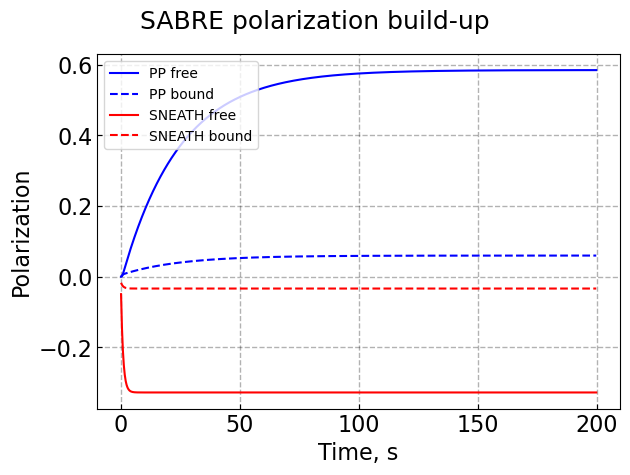

In [15]:
fig, (ax1) = plt.subplots(nrows=1)

timescale = tau_pp * (np.arange(n_cycle) + 1) 
ax1.plot(timescale, P_S['PP']['free'], 'b', label='PP free')
ax1.plot(timescale, P_S['PP']['bound'], 'b--', label='PP bound')
ax1.plot(timescale, P_S['SNEATH']['free'], 'r', label='SNEATH free')
ax1.plot(timescale, P_S['SNEATH']['bound'], 'r--', label='SNEATH bound')
ax1.legend()

ax1.set_xlabel('Time, s',fontsize=16)

ax1.set_ylabel('Polarization',fontsize=16)

ax1.tick_params( axis='both', which='major', labelsize=16,direction='in')

ax1.grid(axis="x", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")
ax1.grid(axis="y", which= 'major', color="black", alpha=.3, linewidth=1, linestyle="--")

fig.suptitle(f"SABRE polarization build-up" ,fontsize=18)
plt.tight_layout()

Optimizing 

## K0 vs Phase

Let's estimate k0 vs phase.

### PP

#### Ideal Pulses

In [16]:
tau_pp_0 = pulse_pol_params(7.7, phi=0)

In [17]:
kds = np.geomspace(1, 300, 40)
phs = np.linspace(-7 * np.pi / 8, 7 * np.pi / 8, 50)
# phs = np.linspace(-3 * np.pi / 4, -np.pi / 2, 90)
tau_pps = np.array(
    [pulse_pol_params(7.7, phi=ph) for ph in phs]
)

P_2 = {
    'free': np.zeros([len(tau_pps),len(kds)]),
    'bound': np.zeros([len(tau_pps),len(kds)])
}
sigma_0_pp = np.hstack([sigma_S, sigma_C])

tau_ppsv, kdsv = np.meshgrid(tau_pps*1e+3, kds, indexing="ij")

In [18]:
time_overall = 50

for i_tau, (tau_pp, ph) in enumerate(zip(tau_pps, phs)):
    pp_sabre = PP_SABRE(
        tau_pp, ss_S, ss_C, 40, W, 
        nuc='15N', b0=B0_PP, ph_shift=ph# , b1_pulse=1e+3
    )
    for i_k, kd in enumerate(kds):
    
        #Set the magnetic field 
        pp_sabre.update(kd=kd)
        uni_pp = pp_sabre.calc()
        #Normalize the steady-state density operator
        n_cycles = int(time_overall / tau_pp)
        uni_fin = np.linalg.matrix_power(uni_pp, n_cycles)

        #Calculate the polarization level
        sigma_fin = uni_fin @ sigma_0_pp
        P_2['free'][i_tau, i_k] = amplitude_v(obs_S, sigma_fin[:idx_S])
        P_2['bound'][i_tau, i_k] = amplitude_v(obs_C, sigma_fin[idx_S:idx_fin])

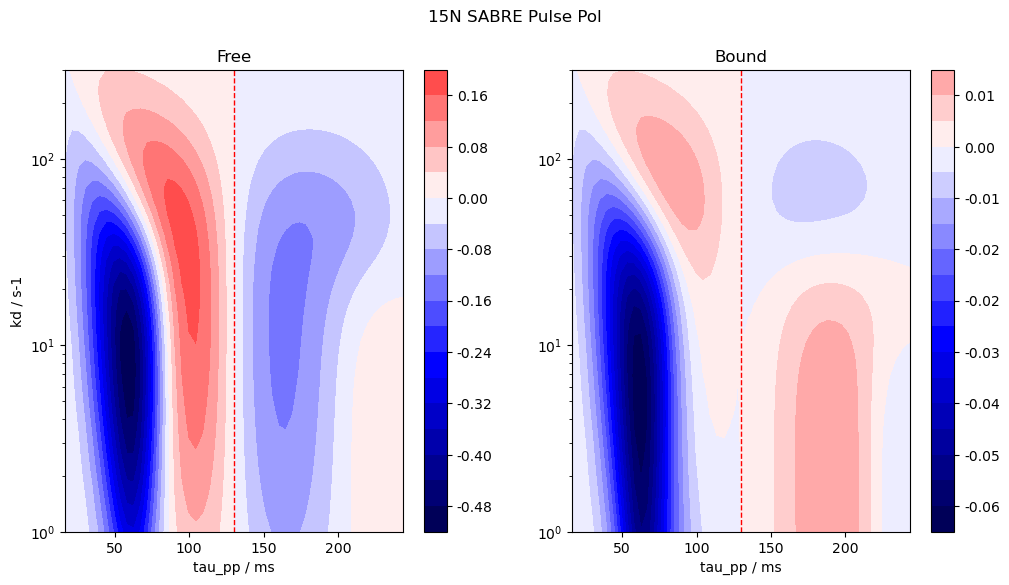

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE Pulse Pol')
my_cmap = 'seismic'


ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    tau_ppsv, kdsv, P_2['free'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel('tau_pp / ms')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
ax1.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    tau_ppsv, kdsv, P_2['bound'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel('tau_pp / ms')
ax2.set_yscale('log')
ax2.set_title('Bound')
ax2.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

In [20]:
kd_target = 40
idx_kd = arg_nearest(kds, kd_target)
tau_pp_best = tau_pps[np.abs(P_2['free'][:, idx_kd]).argmax()]
ph_pp_best = phs[np.abs(P_2['free'][:, idx_kd]).argmax()] 

print(
    f'IDEAL PULSE\n'
    f'For a kd = {kd_target} s-1\n'
    f'The best tau_pp should be {tau_pp_best*1e+3:.2f} ms\n'
    f'With the best phase {ph_pp_best * 180 / np.pi:.1f}\n'
    f'For the polarization {np.abs(P_2['free'])[:, idx_kd].max():.2f}\n'
)

IDEAL PULSE
For a kd = 40 s-1
The best tau_pp should be 48.70 ms
With the best phase -112.5
For the polarization 0.29



#### Real 1 mT pulses

In [21]:
time_overall = 50
P_2_real = {
    'free'  : np.zeros([len(tau_pps),len(kds)]),
    'bound' : np.zeros([len(tau_pps),len(kds)])
}
for i_tau, (tau_pp, ph) in enumerate(zip(tau_pps, phs)):
    pp_sabre = PP_SABRE(
        tau_pp, ss_S, ss_C, kd, W, 
        nuc='15N', b0=B0_PP, ph_shift=ph, b1_pulse=1e-3
    )
    for i_k, kd in enumerate(kds):
        pp_sabre.update(kd=kd)
        uni_pp = pp_sabre.calc()
        #Normalize the steady-state density operator
        n_cycles = int(time_overall / tau_pp)
        uni_fin = np.linalg.matrix_power(uni_pp, n_cycles)

        #Calculate the polarization level
        sigma_fin = uni_fin @ sigma_0_pp
        P_2_real['free'][i_tau, i_k] = amplitude_v(obs_S, sigma_fin[:idx_S])
        P_2_real['bound'][i_tau, i_k] = amplitude_v(obs_C, sigma_fin[idx_S:idx_fin])

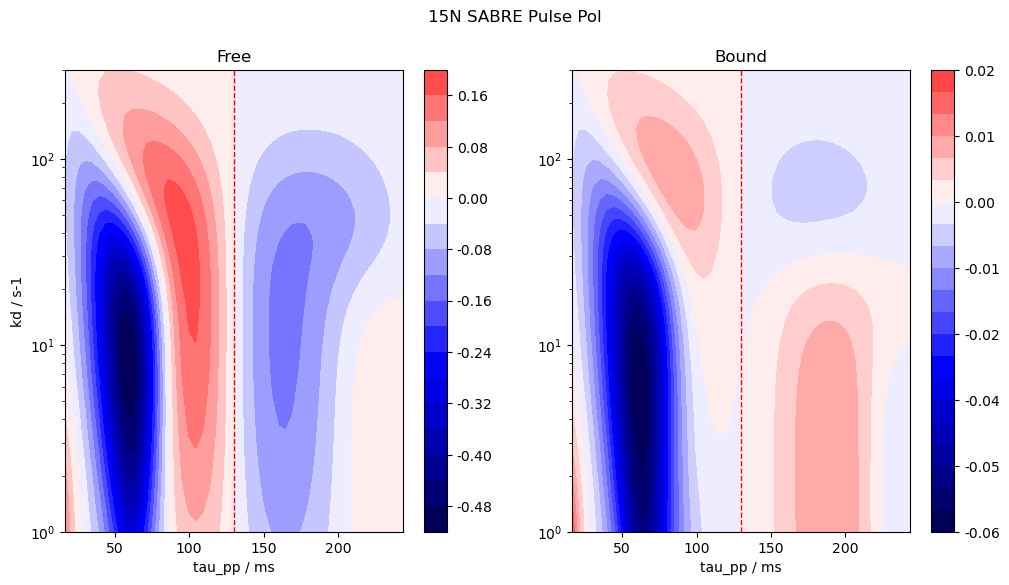

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE Pulse Pol')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    tau_ppsv, kdsv, P_2_real['free'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel('tau_pp / ms')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
ax1.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    tau_ppsv, kdsv, P_2_real['bound'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel('tau_pp / ms')
ax2.set_yscale('log')
ax2.set_title('Bound')
ax2.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

In [23]:
kd_target = 40
idx_kd = arg_nearest(kds, kd_target)
tau_pp_best = tau_pps[np.abs(P_2['free'][:, idx_kd]).argmax()]
ph_pp_best = phs[np.abs(P_2['free'][:, idx_kd]).argmax()] 

print(
    f'1 mT Pulse\n'
    f'For a kd = {kd_target} s-1\n'
    f'The best tau_pp should be {tau_pp_best*1e+3:.2f} ms\n'
    f'With the best phase {ph_pp_best * 180 / np.pi:.1f}\n'
    f'For the polarization {np.abs(P_2['free'])[:, idx_kd].max():.2f}\n'
)

1 mT Pulse
For a kd = 40 s-1
The best tau_pp should be 48.70 ms
With the best phase -112.5
For the polarization 0.29



Cool, there is no big difference.

#### Real 185 uT pulses

In [24]:
time_overall = 50
b1_pulse = 185e-6
P_2_real = {
    'free'  : np.zeros([len(tau_pps),len(kds)]),
    'bound' : np.zeros([len(tau_pps),len(kds)])
}
for i_tau, (tau_pp, ph) in enumerate(zip(tau_pps, phs)):
    pp_sabre = PP_SABRE(
        tau_pp, ss_S, ss_C, kd, W, 
        nuc='15N', b0=B0_PP, ph_shift=ph, b1_pulse=b1_pulse
    )
    for i_k, kd in enumerate(kds):
        pp_sabre.update(kd=kd)
        uni_pp = pp_sabre.calc()
        #Normalize the steady-state density operator
        n_cycles = int(time_overall / tau_pp)
        uni_fin = np.linalg.matrix_power(uni_pp, n_cycles)

        #Calculate the polarization level
        sigma_fin = uni_fin @ sigma_0_pp
        P_2_real['free'][i_tau, i_k] = amplitude_v(obs_S, sigma_fin[:idx_S])
        P_2_real['bound'][i_tau, i_k] = amplitude_v(obs_C, 
                                                    sigma_fin[idx_S:idx_fin])

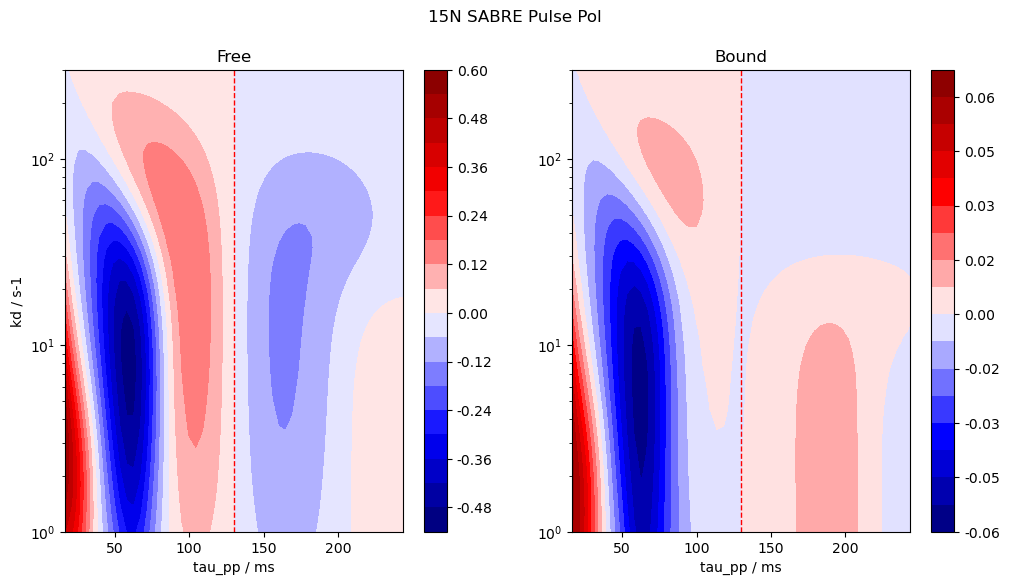

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE Pulse Pol')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    tau_ppsv, kdsv, P_2_real['free'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel('tau_pp / ms')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
ax1.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    tau_ppsv, kdsv, P_2_real['bound'], levels=20, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel('tau_pp / ms')
ax2.set_yscale('log')
ax2.set_title('Bound')
ax2.axvline(tau_pp_0*1e+3, color='red', lw=1, linestyle='--')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

In [26]:
kd_target = 40
idx_kd = arg_nearest(kds, kd_target)
tau_pp_best = tau_pps[np.abs(P_2['free'][:, idx_kd]).argmax()]
ph_pp_best = phs[np.abs(P_2['free'][:, idx_kd]).argmax()] 

print(
    f'185 uT Pulse PP\n'
    f'For a kd = {kd_target} s-1\n'
    f'The best tau_pp should be {tau_pp_best*1e+3:.2f} ms\n'
    f'With the best phase {ph_pp_best * 180 / np.pi:.1f}\n'
    f'For the polarization {np.abs(P_2['free'])[:, idx_kd].max():.2f}\n'
)

185 uT Pulse PP
For a kd = 40 s-1
The best tau_pp should be 48.70 ms
With the best phase -112.5
For the polarization 0.29



So, everything is the same.

### SABRE-SHEATH

In [27]:
B0s = np.linspace(0, 3e-6, 50)

P_2_SHEATH = {
    'free'  : np.zeros([len(tau_pps),len(kds)]),
    'bound' : np.zeros([len(tau_pps),len(kds)])
}
sigma_0_SHEATH = np.hstack([sigma_S, sigma_C])

B0sv, kdsv = np.meshgrid(B0s*1e+6, kds, indexing="ij")

In [28]:
time_overall = 50
for i_B0, B0 in enumerate(B0s):
    for i_k, kd in enumerate(kds):
        uni_sheath = expm(
            SABRE_SO(ss_S, ss_C, B0, kd, W) * time_overall
        )
        sigma_fin = uni_sheath @ sigma_0_pp
        P_2_SHEATH['free'][i_B0, i_k] = amplitude_v(obs_S, sigma_fin[:idx_S])
        P_2_SHEATH['bound'][i_B0, i_k] = amplitude_v(obs_C, sigma_fin[idx_S:idx_fin])

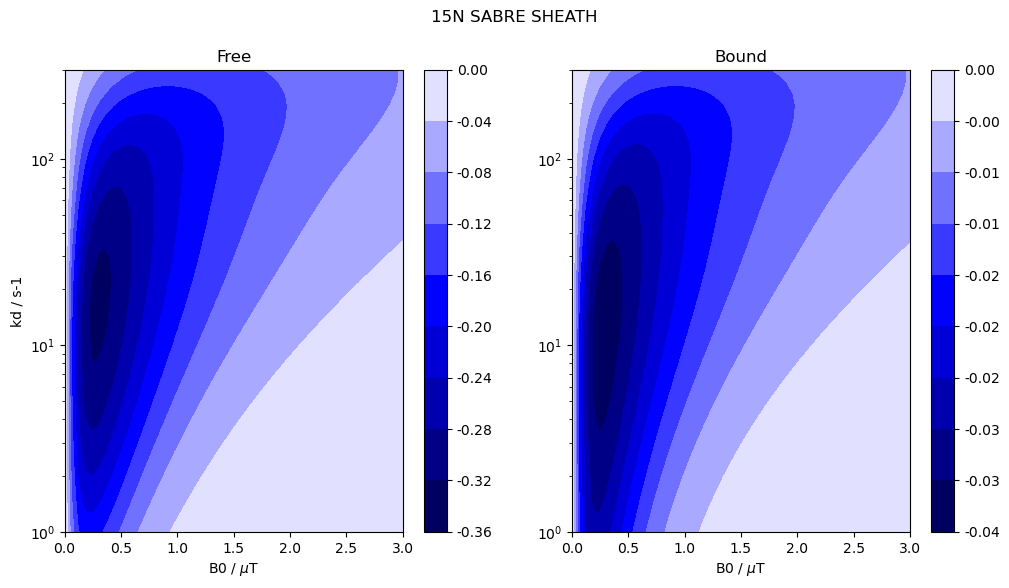

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE SHEATH')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    B0sv, kdsv, P_2_SHEATH['free'], levels=10, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel(r'B0 / $\mu$T')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    B0sv, kdsv, P_2_SHEATH['bound'], levels=10, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel(r'B0 / $\mu$T')
ax2.set_yscale('log')
ax2.set_title('Bound')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

In [30]:
kd_target = 40
B0_SHEATH_best_target = B0s[np.abs(P_2_SHEATH['free'][:, arg_nearest(kds, kd_target)]).argmax()]
ind_max = np.unravel_index(
    np.abs(P_2_SHEATH['free']).argmax(), P_2_SHEATH['free'].shape
)

B0_SHEATH_best = B0s[ind_max[0]]
kd_SHEATH_best = kds[ind_max[1]]
print(
    f'SABRE-SHEATH\n'
    f'For a kd = {kd_target} s-1\n'
    f'The best B0 should be {B0_SHEATH_best_target*1e+9:.2f} nT\n'
    f'For the polarization {np.abs(P_2_SHEATH['free'][:, arg_nearest(kds, kd_target)]).max():.2f}\n'
    f'=====\n'
    f'The best kd is {kd_SHEATH_best:.2f} s-1\n'
    f'With B0 = {B0_SHEATH_best*1e+9:.2f} nT\n'
    f'With Polarization {np.abs(P_2_SHEATH['free'][ind_max]):.2f}'
)

SABRE-SHEATH
For a kd = 40 s-1
The best B0 should be 367.35 nT
For the polarization 0.31
=====
The best kd is 16.10 s-1
With B0 = 306.12 nT
With Polarization 0.33


Which is x2 worse compared to SABRE_PP

Let's also write the coherent SHIELD.

In [31]:
time_overall_coh = 1
timesteps = 1_000
times_SHEATH_coh = np.linspace(0, time_overall_coh, timesteps)
ampls_SHEATH_coh = np.zeros(len(times_SHEATH_coh))
rho_target = -ss_C.pol_level(2, "z")
rho_start = ss_C.singlet(*[0, 1])

ham_SHEATH = ss_C.build_ham_lab(
    field=B0_SHEATH_best, ZULF=True
)

traj_res = traj_prop_h(
    rho_start, ham_SHEATH, times_SHEATH_coh, 
    [rho_target], system=ss_C
)

ampls_SHEATH_coh[:] = traj_res[0]

C:\Users\BogdanRodin\AppData\Local\Temp\ipykernel_17440\3740092837.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  ampls_SHEATH_coh[:] = traj_res[0]


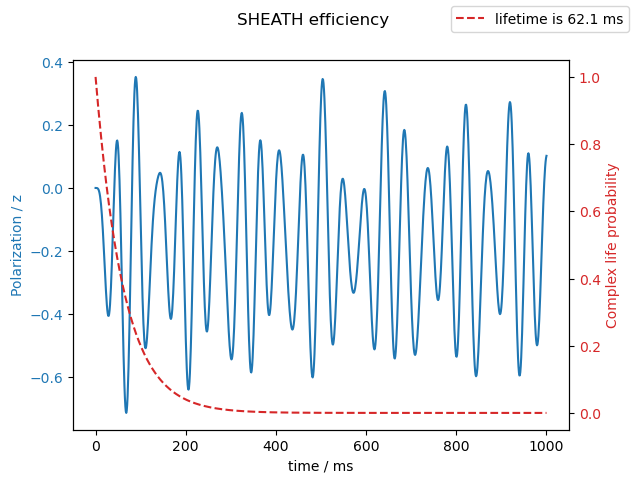

In [32]:
fig, ax1 = plt.subplots()

# First Y-axis
ax1.set_xlabel('time / ms')
ax1.set_ylabel('Polarization / z', color='tab:blue')
ax1.plot(times_SHEATH_coh * 1e+3, ampls_SHEATH_coh, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Second Y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Complex life probability', color='tab:red')  # Modify label
ax2.plot(times_SHEATH_coh * 1e+3, np.exp(-kd_SHEATH_best * times_SHEATH_coh), 
         color='tab:red', linestyle='dashed', 
         label=f'lifetime is {1e+3 / kd_SHEATH_best:.1f} ms')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.suptitle('SHEATH efficiency')
fig.legend(loc="upper right")

plt.show()


In [33]:
print(
    'The mean polarization for SHEATH is '
    f'{ampls_SHEATH_coh.mean():.2f}'
)

The mean polarization for SHEATH is -0.17


### SLIC-SABRE

B0 = 100 uT, B1 = J (-21)

In [34]:
B1s = np.linspace(0, 50, 50)

P_2_SLIC = {
    'free'  : np.zeros([len(B1s),len(kds)]),
    'bound' : np.zeros([len(B1s),len(kds)])
}
sigma_0_SLIC = np.hstack([sigma_S, sigma_C])

B1sv, kdsv = np.meshgrid(B1s, kds, indexing="ij")

obs_S_SLIC = mat2vec(ss_S.pol_level(0, 'x'))
obs_C_SLIC = mat2vec(ss_C.pol_level(2, 'x'))

In [35]:
B0 = 100e-6
time_overall = 50
for i_B1, B1 in enumerate(B1s):
    for i_k, kd in enumerate(kds):
        uni_slic = expm(
            SABRE_SO(ss_S, ss_C, B0, kd, W, omega_n=2*np.pi*B1, on_res=['15N']) * time_overall
        )
        sigma_fin = uni_slic @ sigma_0_SLIC
        P_2_SLIC['free'][i_B1, i_k] = amplitude_v(obs_S_SLIC, sigma_fin[:idx_S])
        P_2_SLIC['bound'][i_B1, i_k] = amplitude_v(obs_C_SLIC, sigma_fin[idx_S:idx_fin])

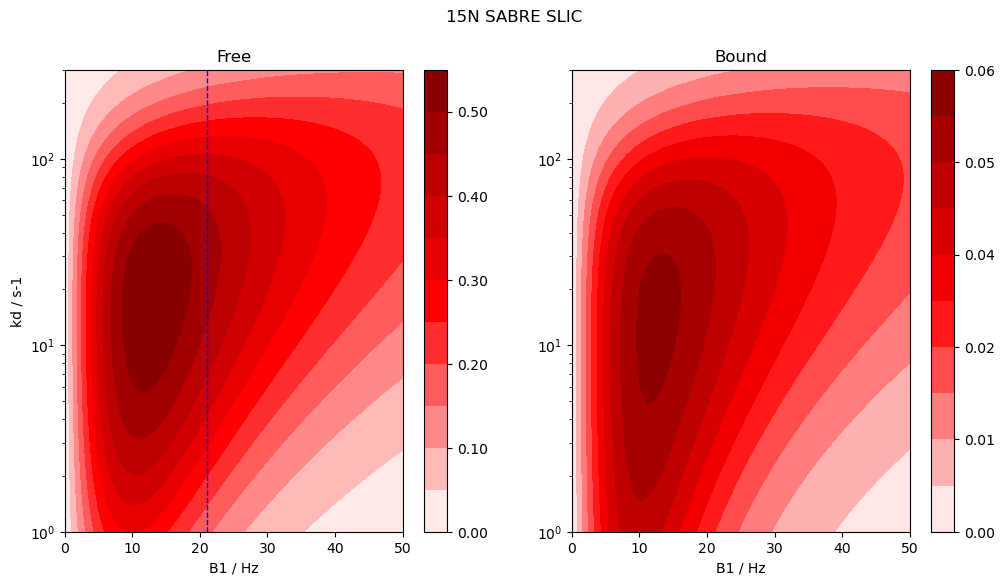

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE SLIC')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    B1sv, kdsv, P_2_SLIC['free'], levels=10, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax1.axvline(21, color='blue', lw=1, linestyle='--')


ax1.set_xlabel(r'B1 / Hz')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
fig.colorbar(cs1, ax=ax1, format='%.2f')

cs2 = ax2.contourf(
    B1sv, kdsv, P_2_SLIC['bound'], levels=10, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel(r'B1 / Hz')
ax2.set_yscale('log')
ax2.set_title('Bound')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

In [37]:
kd_target = 40
B1_SLIC_best_target = B1s[np.abs(P_2_SLIC['free'][:, arg_nearest(kds, kd_target)]).argmax()] 

ind_max = np.unravel_index(
    np.abs(P_2_SLIC['free']).argmax(), P_2_SLIC['free'].shape
)
B1_SLIC_best = B1s[ind_max[0]]
kd_SLIC_best = kds[ind_max[1]]
print(
    f'100 uT SLIC-SABRE\n'
    f'For a kd = {kd_target} s-1\n'
    f'The best B1 should be {B1_SLIC_best_target:.2f} Hz\n'
    f'For the polarization {np.abs(P_2_SLIC['free'][:, arg_nearest(kds, kd_target)]).max():.2f}\n'
    f'=====\n'
    f'The best kd is {kd_SLIC_best:.2f} s-1\n'
    f'With B1 = {B1_SLIC_best:.2f} Hz\n'
    f'With Polarization {P_2_SLIC['free'][ind_max]:.2f}'
)

100 uT SLIC-SABRE
For a kd = 40 s-1
The best B1 should be 14.29 Hz
For the polarization 0.52
=====
The best kd is 18.63 s-1
With B1 = 12.24 Hz
With Polarization 0.54


In [38]:
time_overall_coh = 1
timesteps = 10_000
times_SLIC_coh = np.linspace(0, time_overall_coh, timesteps)
ampls_SLIC_coh = np.zeros(len(times_SLIC_coh))
ampls_SLIC_coh_2 = np.zeros(len(times_SLIC_coh))

target_ops = [
    -ss_C.pol_level(2, "x"), -ss_C.pol_level(2, "z")
]
rho_start = ss_C.singlet(*[0, 1])

ham_SLIC = ss_C.build_ham_rf(
    field=B0, 
    nucs_on_res=['15N']
)

### SLIC
ham_add = 2 * np.pi * B1_SLIC_best * ss_C.op(2, 'x')

traj_res = traj_prop_h(
    rho_start, ham_SLIC + ham_add, times_SLIC_coh, 
    target_ops, system=ss_C
)

ampls_SLIC_coh[:] = np.sqrt(traj_res[0]**2 + traj_res[1]**2) 

### 2res SLIC
ham_SLIC = ss_C.build_ham_rf(
    field=B0, 
    nucs_on_res=['15N', '1H']
)

# nu_H = 23.33
# nu_N = 10
# off_N = 30

nu_H = 64
nu_N = 24
off_N = 68


ham_add = 2 * np.pi * (
    nu_H * ss_C.op([0, 1], 'x')
    + off_N * ss_C.op(2, 'z') 
    + nu_N * ss_C.op(2, 'x')
)

traj_res = traj_prop_h(
    rho_start, ham_SLIC + ham_add, times_SLIC_coh, 
    target_ops, system=ss_C
)

ampls_SLIC_coh_2[:] = np.sqrt(traj_res[0]**2 + traj_res[1]**2) 


C:\Users\BogdanRodin\AppData\Local\Temp\ipykernel_17440\2977620733.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  ampls_SLIC_coh[:] = np.sqrt(traj_res[0]**2 + traj_res[1]**2)
C:\Users\BogdanRodin\AppData\Local\Temp\ipykernel_17440\2977620733.py:53: ComplexWarning: Casting complex values to real discards the imaginary part
  ampls_SLIC_coh_2[:] = np.sqrt(traj_res[0]**2 + traj_res[1]**2)


c:\Users\BogdanRodin\miniconda3\envs\spinsim\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\BogdanRodin\miniconda3\envs\spinsim\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


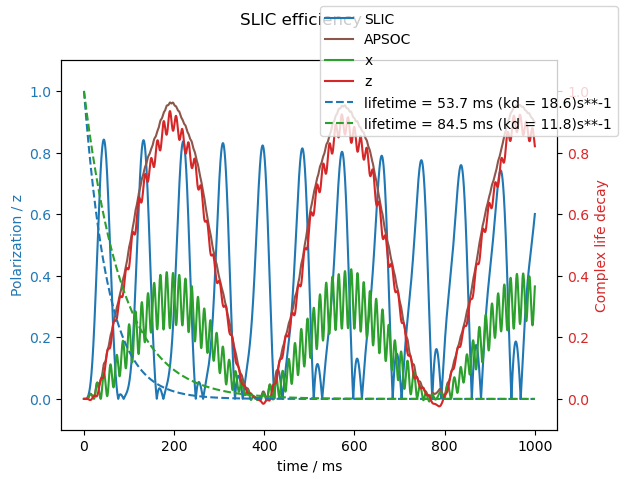

In [41]:
fig, ax1 = plt.subplots()

# First Y-axis
ax1.set_xlabel('time / ms')
ax1.set_ylabel('Polarization / z', color='tab:blue')
ax1.plot(
    times_SLIC_coh * 1e+3, ampls_SLIC_coh, 
    color='tab:blue', label='SLIC'
)

ax1.plot(
    times_SLIC_coh * 1e+3, ampls_SLIC_coh_2, 
    color='tab:brown', label='APSOC'
)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.plot(
    times_SLIC_coh * 1e+3, traj_res[0], 
    color='tab:green', label='x'
)

ax1.plot(
    times_SLIC_coh * 1e+3, traj_res[1], 
    color='tab:red', label='z'
)

ax1.tick_params(axis='y', labelcolor='tab:blue')


# Second Y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Complex life decay', color='tab:red')  # Modify label
ax2.plot(times_SLIC_coh * 1e+3, np.exp(-kd_SLIC_best * times_SLIC_coh), 
         color='tab:blue', linestyle='dashed', 
         label=f'lifetime = {1e+3 / kd_SLIC_best:.1f} ms (kd = {kd_SLIC_best:.1f})s**-1')

kd_loc = 11.84
ax2.plot(
    times_SLIC_coh * 1e+3, np.exp(-kd_loc * times_SLIC_coh), 
    color='tab:green', linestyle='dashed', 
    label=f'lifetime = {1e+3 / kd_loc:.1f} ms (kd = {kd_loc:.1f})s**-1')

ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.set_ylim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
fig.suptitle('SLIC efficiency')
fig.legend(loc="upper right")

plt.show()

In [ ]:
nu_eff = np.sqrt(nu_N**2 + off_N**2)
print(f'Effective field {nu_eff:.2f}')
print(f'J + nu_H = {(np.abs(ss_C.Js[0, 1]) + nu_H):.2f}')

Effective field 72.11
J + nu_H = 71.70


Potential $\omega_{\text{LAC}}$ estimation is:

In [ ]:
omega_lac_potential = np.abs(
    ss_C.Js[0, 2] * nu_N / nu_eff
) / 2

print(f'Potential lac is {2 * np.pi * omega_lac_potential:.2f}')

Potential lac is 21.96


Let's see the maximum amplitdue for SLIC.

In [ ]:
nu_SLIC = 1 / times_SLIC_coh[ampls_SLIC_coh.argmax()]
nu_APOSC = 1 / 0.380
print(f'omega_LAC for SLIC is {nu_SLIC * 2 * np.pi:.2f} rad * s*-1')
print(f'k_d optim for SLIC is {kd_SLIC_best:.2f} s*-1')

print(f'omega_LAC for APSOC is {nu_APOSC * 2 * np.pi:.2f} rad * s*-1')
print(f'k_d optim for SLIC is {kd_loc:.2f} s*-1')

omega_LAC for SLIC is 142.79 rad * s*-1
k_d optim for SLIC is 18.63 s*-1
omega_LAC for APSOC is 16.53 rad * s*-1
k_d optim for SLIC is 11.84 s*-1


### ALL METHODS

In [ ]:
kds = np.geomspace(1, 300, 40)
phs = np.linspace(-7 * np.pi / 8, 7 * np.pi / 8, 50)
tau_pps = np.array(
    [pulse_pol_params(7.7, phi=ph) for ph in phs]
)
time_overall = 50

Let's pickle it to avoid recalculation.

In [ ]:
def compute_or_load_results(filename, kds, phs, tau_pps, time_overall=50):
    if os.path.exists(filename):
        print("Loading existing results...")
        return np.load(filename, allow_pickle=True).item()
    
    print("Computing results...")
    P_2_long = {
        'free': np.zeros([len(tau_pps), len(phs), len(kds)]),
        'bound': np.zeros([len(tau_pps), len(phs), len(kds)]),
    }
    
    sigma_0_pp = np.hstack([sigma_S, sigma_C])
    
    for i_ph, ph in enumerate(phs):
        for i_tau, tau_pp in enumerate(tau_pps):
            pp_sabre = PP_SABRE(
                tau_pp, ss_S, ss_C, 40, W, 
                nuc='15N', b0=B0_PP, ph_shift=ph
            )
            for i_k, kd in enumerate(kds):
                pp_sabre.update(kd=kd, tau_pp=tau_pp)
                uni_pp = pp_sabre.calc()
                n_cycles = int(time_overall / tau_pp)
                uni_fin = np.linalg.matrix_power(uni_pp, n_cycles)
                sigma_fin = uni_fin @ sigma_0_pp
                P_2_long['free'][i_tau, i_ph, i_k] = amplitude_v(
                    obs_S, sigma_fin[:idx_S]
                )
                P_2_long['bound'][i_tau, i_ph, i_k] = amplitude_v(
                    obs_C, sigma_fin[idx_S:idx_fin]
                )
    
    np.save(filename, P_2_long)
    return P_2_long

In [ ]:
filename = 'SABRE_PP_res/pol_all_depenecies.npy'
P_2_long = compute_or_load_results(filename, kds, phs, tau_pps)

Loading existing results...


#### Finding the maximum values

In [ ]:
# tau, phase, k_d
P_2_free = P_2_long['free']
P_2_argmax_phase = np.argmax(np.abs(P_2_free), axis=1)
P_2_argmax_tau = np.argmax(np.abs(P_2_free), axis=0)

Let's try to see what's going on for tau maximization.

In [ ]:
P_2_max = {
    'tau': np.take_along_axis(
        P_2_free, P_2_argmax_phase[:, None, :], axis=1
    ).squeeze(),
    'phase' : np.take_along_axis(
        P_2_free, P_2_argmax_tau[None, :, :], axis=0
    ).squeeze()
}

Ok, let's try and plot.

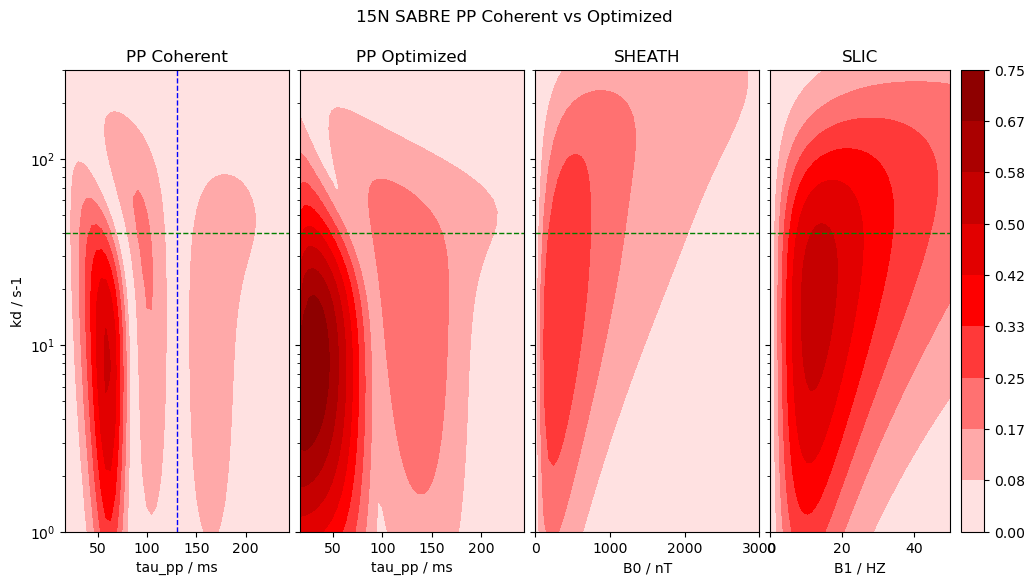

In [ ]:
fig, axs = plt.subplots(
    1, 4, figsize=(12, 6), sharey=True
)

fig.suptitle('15N SABRE PP Coherent vs Optimized')
my_cmap = 'seismic'


ax1 = axs[0]
ax2 = axs[1]
ax3 = axs[2]
ax4 = axs[3]

levels = np.linspace(
    0, np.max(P_2_max['tau']), 10
)

cs1 = ax1.contourf(
    tau_ppsv, kdsv, np.abs(P_2['free']), levels=levels, 
    cmap=my_cmap, norm=CenteredNorm()
)


ax1.set_xlabel('tau_pp / ms')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('PP Coherent')
ax1.axvline(tau_pp_0*1e+3, color='blue', lw=1, linestyle='--')


cs2 = ax2.contourf(
    tau_ppsv, kdsv, np.abs(P_2_max['tau']), levels=levels, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax2.set_xlabel('tau_pp / ms')
ax2.set_yscale('log')
ax2.set_title('PP Optimized')


cs3 = ax3.contourf(
    B0sv *1e+3, kdsv, np.abs(P_2_SHEATH['free']), levels=levels, 
    cmap=my_cmap, norm=CenteredNorm()
)
ax3.set_xlabel('B0 / nT')
ax3.set_yscale('log')
ax3.set_title('SHEATH')


cs4 = ax4.contourf(
    B1sv, kdsv, np.abs(P_2_SLIC['free']), levels=levels, 
    cmap=my_cmap, norm=CenteredNorm()
)

ax4.set_xlabel('B1 / HZ')
ax4.set_yscale('log')
ax4.set_title('SLIC')
# ax4.set_yticks([])

fig.colorbar(cs2, ax=ax4, format='%.2f')

# Reduce the space between subplots
fig.subplots_adjust(wspace=0.05)

for ax in axs:
    ax.axhline(40, color='green', lw=1, linestyle='--')

plt.show()

In [ ]:
kd_target = 40
idx_kd_target = arg_nearest(kds, kd_target)
print(
    'MAX EFFICIENCY FOR DIFFERENT METHODS\n',
    f'kd={kd_target}\n'
    f'COHERENT PP: {np.abs(P_2["free"])[:, idx_kd_target].max():.2f}\n',
    f'OPTIMIZED PP: {np.abs(P_2_max["tau"])[:, idx_kd_target].max():.2f}\n',
    f'SHEATH : {np.abs(P_2_SHEATH["free"])[:, idx_kd_target].max():.2f}\n',
    f'SLIC: {np.abs(P_2_SLIC["free"])[:, idx_kd_target].max():.2f}\n',
)

MAX EFFICIENCY FOR DIFFERENT METHODS
 kd=40
COHERENT PP: 0.29
 OPTIMIZED PP: 0.46
 SHEATH : 0.31
 SLIC: 0.52



In [ ]:
kd_target = 10
idx_kd_target = arg_nearest(kds, kd_target)
print(
    'MAX EFFICIENCY FOR DIFFERENT METHODS\n',
    f'kd={kd_target}\n'
    f'COHERENT PP: {np.abs(P_2["free"])[:, idx_kd_target].max():.2f}\n',
    f'OPTIMIZED PP: {np.abs(P_2_max["tau"])[:, idx_kd_target].max():.2f}\n',
    f'SHEATH : {np.abs(P_2_SHEATH["free"])[:, idx_kd_target].max():.2f}\n',
    f'SLIC: {np.abs(P_2_SLIC["free"])[:, idx_kd_target].max():.2f}\n',
)

MAX EFFICIENCY FOR DIFFERENT METHODS
 kd=10
COHERENT PP: 0.51
 OPTIMIZED PP: 0.74
 SHEATH : 0.33
 SLIC: 0.53



Let's find the base phase and tau for a given k_d

In [ ]:
max_kd = P_2_free[:, :, arg_nearest(kds, 40)]
ind_max = np.unravel_index(
    np.argmax(max_kd),  max_kd.shape
) 

In [ ]:
kd_target = 40

P_2_free_for_given_kd = P_2_free[:, :, arg_nearest(kds, kd_target)]
ind_max_target = np.unravel_index(
    np.argmax(P_2_free_for_given_kd),  
    P_2_free_for_given_kd.shape
) 

ind_max = np.unravel_index(
    np.abs(P_2_free).argmax(),  
    P_2_free.shape
) 

kd_pp_max = kds[ind_max[2]]
tau_pp_max = tau_pps[ind_max[0]]
ph_pp_max = phs[ind_max[1]]

print(
    f'SABRE-PP, parameter space search, kd={kd_target} s-1',
    f'The time argmax is {tau_pps[ind_max_target[0]]*1e+3:.0f} ms',
    f'The phase argmax is {phs[ind_max_target[1]] * 180 / np.pi:.2f}',
    f'Polarization is {P_2_free_for_given_kd[ind_max_target]:.2f}',
    f'===',
    f'THE MOST OPTIMAL PARAMS:',
    f'Polarization is {P_2_free[ind_max]:.2f}',
    f'Best kd is {kd_pp_max:.2f} s-1',
    sep='\n'
)


SABRE-PP, parameter space search, kd=40 s-1
The time argmax is 26 ms
The phase argmax is 48.21
Polarization is 0.46
===
THE MOST OPTIMAL PARAMS:
Polarization is -0.75
Best kd is 7.75 s-1


#### Optimal time and phase difference

Let's try and plot one phase-time plot.

In [ ]:
kd_locs = np.geomspace(1, 300, 4)
tau_ppsv, phsv = np.meshgrid(tau_pps*1e+3, phs * 180 / np.pi, indexing="ij")

In [ ]:
fig, axs = plt.subplots(1, len(kd_locs), figsize=(12, 6), sharey=True)

fig.suptitle('15N SABRE PP for different kds')
my_cmap = 'seismic'
n_levels = 10

for idx, (kd_loc, ax) in enumerate(zip(kd_locs, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    cs = ax.contourf(
        tau_ppsv, phsv, P_2_free[:, :, idx_kd], 
        levels=n_levels, cmap=my_cmap, norm=CenteredNorm()
    )

    ax.plot(
        tau_pps * 1e+3, phs * 180 / np.pi, 
        linestyle="--", label='Opt Coherent', color='red'
    )

    if idx == 0:
        ax.set_ylabel('phase / degree')
    ax.set_xlabel('tau_pp / ms')
    ax.set_title(f'kd = {kds[idx_kd]:.1f} s-1')
    
    ax.plot(
        tau_pp_max * 1e+3, ph_pp_max * 180 / np.pi, 'ro', 
        markersize=8, label='Best for SABRE'
    )
    
    if idx == len(kd_locs - 1):
        ax.legend()

    fig.colorbar(cs, ax=ax, format='%.2f')

plt.show()

NameError: name 'plt' is not defined

Let's combine it with different PP plots.

In [ ]:
field_z = 1e-3 # 1 mT
n_pps = [1, 2, 3, 4, 5]
ampls_PP_coh = np.zeros(
    (len(tau_pps), len(phs), len(n_pps))
)

ham_rf = ss_C.build_ham_rf(
    field=field_z, nucs_on_res=['15N']
)

n_pp = 1
rho_target = -ss_C.pol_level(2, "z")
for idx_ph, ph in enumerate(phs):
    pp = PP(
        10e-3, n_pp=n_pp, ham_bg=ham_rf, 
        idx_X=2, spin_system=ss_C, 
        shift=ph, nuclei='15N'
    )
    
    pp.precompile_pulse()
    
    for idx_t, tau_pp in enumerate(tau_pps):
        pp.set_tau_pp(tau_pp)
        for idx_n, n_pp in enumerate(n_pps):
            rho_fin = pp.rho_fin(
                rho=ss_C.singlet(*[0, 1]),
                n_cycle=n_pp
            )
            
            ampls_PP_coh[idx_t, idx_ph, idx_n] = np.real(
                amplitude(
                    rho_target,
                    rho_fin
                )
            )

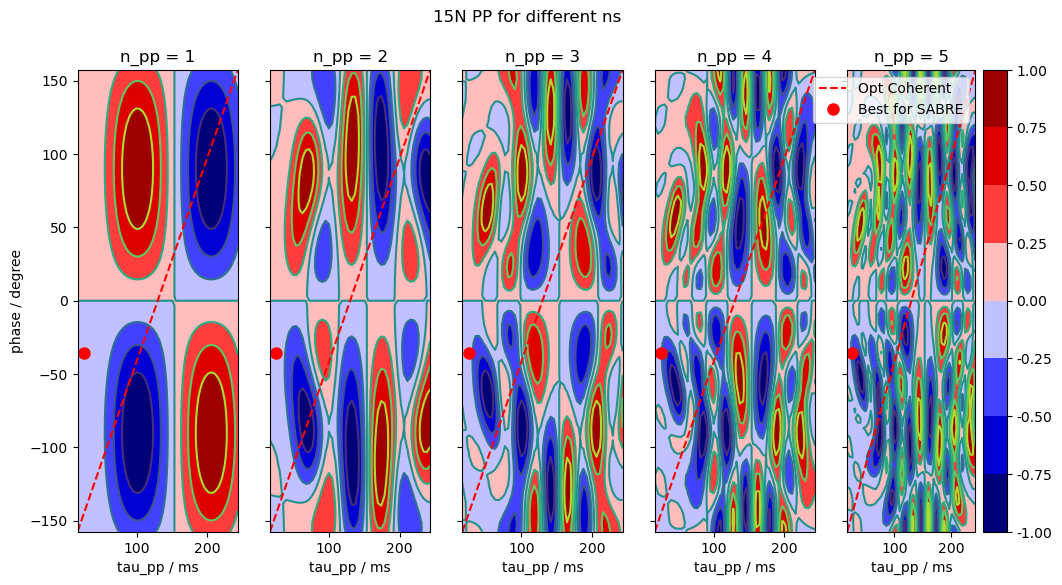

In [ ]:
fig, axs = plt.subplots(1, len(n_pps), figsize=(12, 6), sharey=True)

fig.suptitle(f'15N PP for different ns')
my_cmap = 'seismic'
n_levels = 7

for idx_n, (n_pp, ax) in enumerate(zip(n_pps, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    cs = ax.contourf(
        tau_ppsv, phsv, 
        ampls_PP_coh[:, :, idx_n], levels=n_levels, 
        cmap=my_cmap, norm=CenteredNorm()
    )

    cl = ax.contour(
        tau_ppsv, phsv, 
        ampls_PP_coh[:, :, idx_n], levels=n_levels, 
        # colors='black', linewidths=1.2  # Adjust thickness
    )
    
    # Optional: Add labels on contour lines
    # ax.clabel(cl, inline=True, fontsize=8, fmt="%.2f")

    ax.plot(
        tau_pps * 1e+3, phs * 180 / np.pi, 
        linestyle="--", label='Opt Coherent', color='red'
    )

    ax.plot(
        tau_pp_max * 1e+3, ph_pp_max * 180 / np.pi, 'ro', 
        markersize=8, label='Best for SABRE'
    )
    if idx_n == 0:
        ax.set_ylabel('phase / degree')
    ax.set_xlabel('tau_pp / ms')
    ax.set_title(f'n_pp = {n_pp:.0f}')
    if idx_n == len(kd_locs - 1):
        ax.legend()

        fig.colorbar(cs, ax=ax, format='%.2f')

plt.show()

Dependence on the n_cycles.

In [ ]:
# Helpers #
op_C = ss_C.op
idx_X = 2
ph_x = 0
ph_y = np.pi * 0.5

# 
tau_overall = 1
n_points = 2048 * 12
n_cycles = int(tau_overall / tau_pp_max)
n_points_local = int(n_points / n_cycles / 4)  
times_pp = np.linspace(0, tau_pp_max / 4, n_points_local)

times_pp_overall = np.linspace(
    0, tau_pp_max * n_cycles, 4 * n_points_local * n_cycles
)

###
pol_x, pol_y, pol_z = (
    ss_C.pol_level(idx_X, "x"), 
    ss_C.pol_level(idx_X, "y"), 
    ss_C.pol_level(idx_X, "z")   
)
rho_start = ss_C.singlet(*[0, 1])

a_90 = np.pi / 2
a_180 = 2 * a_90
field_z = 1e-3
ham_pp = ss_C.build_ham_rf(field=field_z, nucs_on_res=['15N'])

ham_pp_cycle = [
    a_90 * op_C(idx_X, phi=ph_y),
    [ham_pp, times_pp],
    a_180 * op_C(idx_X, phi=ph_x),
    [ham_pp, times_pp],
    a_90 * op_C(idx_X, phi=ph_y),
    # === half of the sequence === #
    a_90 * op_C(idx_X, phi=ph_y+ph_pp_max),
    [ham_pp, times_pp],
    a_180 * op_C(idx_X, phi=ph_x+ph_pp_max),
    [ham_pp, times_pp],
    a_90 * op_C(idx_X, phi=ph_y+ph_pp_max)
]


In [ ]:
ampls_pp_coh = ampls_seq(
    rho_start, ham_pp_cycle * n_cycles, 
    [pol_x, pol_y, pol_z], ss_C
)

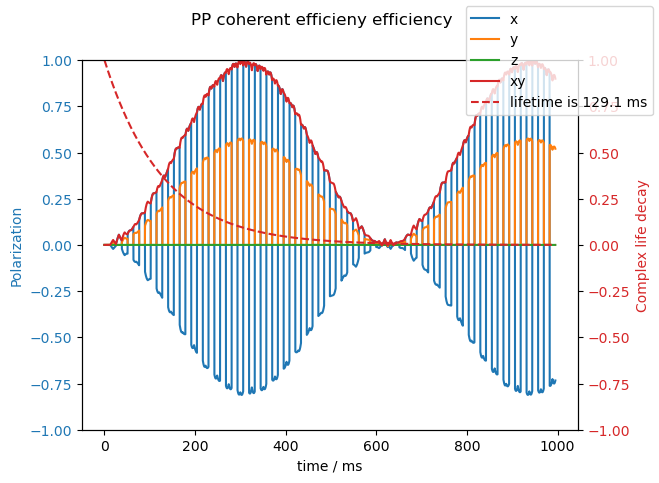

In [ ]:
fig, ax1 = plt.subplots()

# First Y-axis
ax1.set_xlabel('time / ms')
ax1.set_ylabel('Polarization', color='tab:blue')
labels = ['x', 'y', 'z']
for label, ampl_pp in zip(labels, ampls_pp_coh):
    ax1.plot(times_pp_overall*1e+3, ampl_pp, label=f'{label}')

pol_pp_xy = np.sqrt(ampls_pp_coh[0]**2 + ampls_pp_coh[1]**2)

ax1.plot(
    times_pp_overall*1e+3, pol_pp_xy,
    label='xy'
)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(-1, 1)

# Second Y-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Complex life decay', color='tab:red')  # Modify label
ax2.plot(times_pp_overall*1e+3, np.exp(-kd_pp_max * times_pp_overall), 
         color='tab:red', linestyle='dashed', 
         label=f'lifetime is {1e+3 / kd_pp_max:.1f} ms')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.set_ylim(-1, 1)

fig.suptitle('PP coherent efficieny efficiency')
fig.legend(loc="upper right")

plt.show()

In the Andrey's analytical article the biggest coherent enhancement should be achieved when $2 * \pi * \nu_{LAC} = k_d$. Let's see what value we have here.

In [ ]:
nu = 1 / times_pp_overall[pol_pp_xy.argmax()]
print(f'omega_LAC is {2 * np.pi * nu:.2f} rad * s-1')
print(f'The k_d is {kd_pp_max:.2f} s-1')

omega_LAC is 6.63 rad * s-1
The k_d is 7.75 s-1


Let's try and plot it somehow:

In [ ]:
tau_pps_coh = np.zeros(len(kds))
ph_pps_coh = np.zeros(len(kds))

tau_pps_optim = np.zeros(len(kds))
ph_pps_optim = np.zeros(len(kds))

for idx_kd, _ in enumerate(kds):
    
    # Optimal
    max_kd = P_2_free[:, :, idx_kd]
    ind_max = np.unravel_index(
        np.argmax(max_kd),  max_kd.shape
    ) 
    
    tau_pps_optim[idx_kd] = tau_pps[ind_max[0]]
    ph_pps_optim[idx_kd] = phs[ind_max[1]]
    
    
    # Coherent
    idx_tau_coh = np.abs(P_2['free'])[:, idx_kd].argmax()
    tau_pps_coh[idx_kd] = tau_pps[idx_tau_coh]
    ph_pps_coh[idx_kd] = phs[idx_tau_coh]

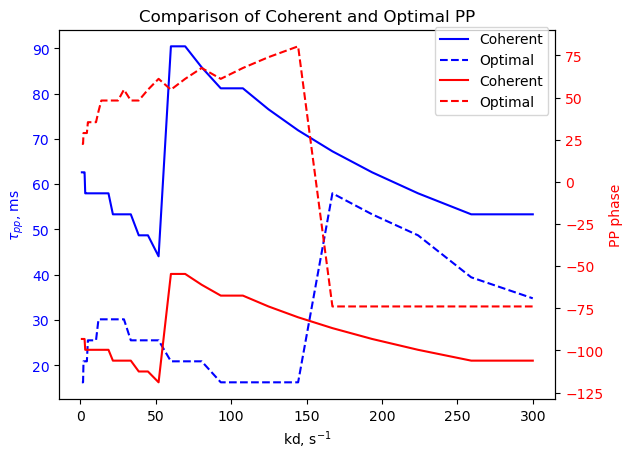

In [ ]:
fig, ax1 = plt.subplots()

# First Y-axis (left)
ax1.plot(kds, tau_pps_coh * 1e+3, label='Coherent', color='blue')
ax1.plot(kds, tau_pps_optim * 1e+3, label='Optimal', color='blue', linestyle='dashed')
ax1.set_xlabel('kd, s$^{-1}$')
ax1.set_ylabel(r'$\tau_{pp}$, ms', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second Y-axis (right)
ax2 = ax1.twinx()
ax2.plot(kds, ph_pps_coh * 180 / np.pi, label='Coherent', color='red')
ax2.plot(kds, ph_pps_optim * 180 / np.pi, label='Optimal', color='red', linestyle='dashed')
ax2.set_ylabel(r'PP phase', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend for both lines
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.title('Comparison of Coherent and Optimal PP')

plt.show()

# NULLSPACE

Small function to suppress neverending outputs from logm.

In [ ]:
import os, sys

class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

## SLIC

In [ ]:
kds = np.geomspace(1, 300, 31)
B1s = np.linspace(0, 50, 31)

P_2_SLIC_NS = {
    'free': np.zeros([len(B1s), len(kds)]),
    'bound': np.zeros([len(B1s), len(kds)])
} 

obs_S_SLIC = ss_S.pol_level(0, 'x')
obs_C_SLIC = ss_C.pol_level(2, 'x')
sigma_0_pp = np.hstack([sigma_S, sigma_C])

In [ ]:
B0 = 100e-6
for i_b1, B1 in enumerate(B1s):
    for i_k, kd in enumerate(kds):
        # Here I suppress annoying outputs
        with HiddenPrints():
            sigma = null_space(
                SABRE_SO(
                    ss_S, ss_C, B0, kd, W, 
                    omega_n=2*np.pi*B1, 
                    on_res=['15N']
                )
            )
        sigma_free = vec2mat(sigma[:idx_S])
        sigma_bound = vec2mat(sigma[idx_S:idx_fin])

        #Normalize the steady-state density operator
        sigma_free = sigma_free / np.trace(sigma_free)
        sigma_bound = sigma_bound / np.trace(sigma_bound)

        P_2_SLIC_NS['free'][i_b1, i_k] = np.real(
            amplitude(obs_S_SLIC, sigma_free)
        )
        P_2_SLIC_NS['bound'][i_b1, i_k] = np.real(
            amplitude(obs_C_SLIC, sigma_bound)
        )

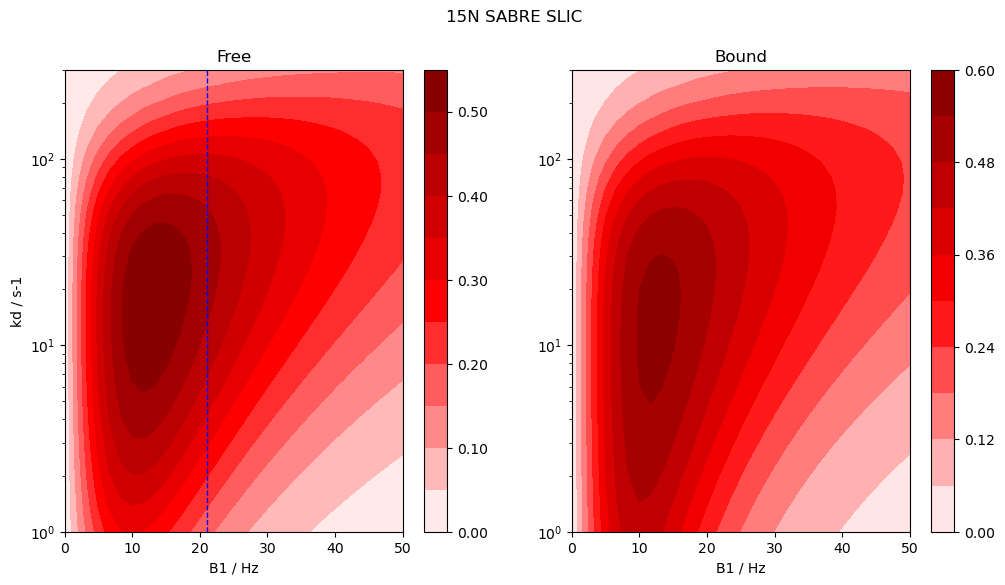

In [ ]:
B1sv, kdsv = np.meshgrid(B1s, kds, indexing="ij")
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle('15N SABRE SLIC')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]

cs1 = ax1.contourf(
    B1sv, kdsv, 
    np.abs(P_2_SLIC_NS['free']), levels=10, 
    cmap=my_cmap, norm=CenteredNorm()
)
ax1.axvline(21, color='blue', lw=1, linestyle='--')
ax1.set_xlabel(r'B1 / Hz')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Free')
fig.colorbar(cs1, ax=ax1, format='%.2f')

#===# 
cs2 = ax2.contourf(
    B1sv, kdsv, 
    np.abs(P_2_SLIC_NS['bound']), levels=10, 
    cmap=my_cmap, norm=CenteredNorm()
)
ax2.set_xlabel(r'B1 / Hz')
ax2.set_yscale('log')
ax2.set_title('Bound')
fig.colorbar(cs2, ax=ax2, format='%.2f')

plt.show()

Something is really off with the bond. Free looks correct.

Let's check off resonance SLIC.

In [ ]:
# kds = np.geomspace(1, 300, 31)
# B1s = np.linspace(0, 50, 31)
# B1sH = np.linspace(0, 50, 31)
# offsets = np.linspace(-60, 60, 51)

B1s = np.linspace(0, 80, 21)
B1sH = np.linspace(0, 80, 21)
offsets = np.linspace(0, 80, 21)

P_2_SLIC_full = {
    'x': np.zeros([len(B1s), len(B1sH), len(offsets), len(kds)]),
    'z': np.zeros([len(B1s), len(B1sH), len(offsets), len(kds)]),
} 

obs_S_SLIC_x = ss_S.pol_level(0, 'x')
obs_C_SLIC_x = ss_C.pol_level(2, 'x')
obs_S_SLIC_z = ss_S.pol_level(0, 'z')
obs_C_SLIC_z = ss_C.pol_level(2, 'z')

sigma_0_pp = np.hstack([sigma_S, sigma_C])

In [ ]:
B0 = 100e-6

result_dir = "SABRE_PP_res"
result_file = "P_2_SLIC_full_long.npz"
os.makedirs(result_dir, exist_ok=True)  # Ensure the directory exists
result_file = os.path.join(result_dir, result_file)

if os.path.exists(result_file):
    print("Loading precomputed results...")
    data = np.load(result_file)
    P_2_SLIC_full = {
        'x': data['x'],
        'z': data['z'],
    }
else:
    print("Performing calculations...")
    for (i_b1, B1), (i_b1h, B1H), (i_b0, offset), (i_k, kd) in product(
        enumerate(B1s), enumerate(B1sH), enumerate(offsets), enumerate(kds)
    ):
        # Here I suppress annoying outputs
        with HiddenPrints():
            sigma = null_space(
                SABRE_SO(
                    ss_S, ss_C, B0, kd, W, 
                    omega_n=2*np.pi*B1,
                    omega_n_H=2*np.pi*B1H,
                    on_res=['1H', '15N'],
                    omega_off=2*np.pi*offset
                )
            )
        sigma_free = vec2mat(sigma[:idx_S])

        #Normalize the steady-state density operator
        sigma_free = sigma_free / np.trace(sigma_free)

        P_2_SLIC_full['x'][i_b1, i_b1h, i_b0, i_k] = np.real(
            amplitude(obs_S_SLIC_x, sigma_free)
        )
        P_2_SLIC_full['z'][i_b1, i_b1h, i_b0, i_k] = np.real(
            amplitude(obs_S_SLIC_z, sigma_free)
        )
                    
    # Save results for future runs
    np.savez_compressed(
        result_file, 
        x=P_2_SLIC_full['x'], z=P_2_SLIC_full['z']
    )
    print("Results saved to", result_file)

Loading precomputed results...


In [ ]:
idx_B1H_null = 0
idx_off_null = 0

# sanity_bool = np.allclose(
#     P_2_SLIC_full['x'][:, idx_B1H_null, idx_off_null, :],
#     P_2_SLIC_NS['free']
# )
# print(f'Sanity check: {sanity_bool}')

In [ ]:
P_SLIC_abs = np.sqrt(
    P_2_SLIC_full['x']**2 + P_2_SLIC_full['z']**2
)

# Different maximal values
P_SLIC_abs_offset = (P_SLIC_abs[:, idx_B1H_null, :, :]).max(axis=1)
P_SLIC_abs_B1H = (P_SLIC_abs[:, :, idx_off_null, :]).max(axis=1)
P_SLIC_abs_max = P_SLIC_abs.max(axis=(1, 2))

Let's see only the dependencies on the offsets.

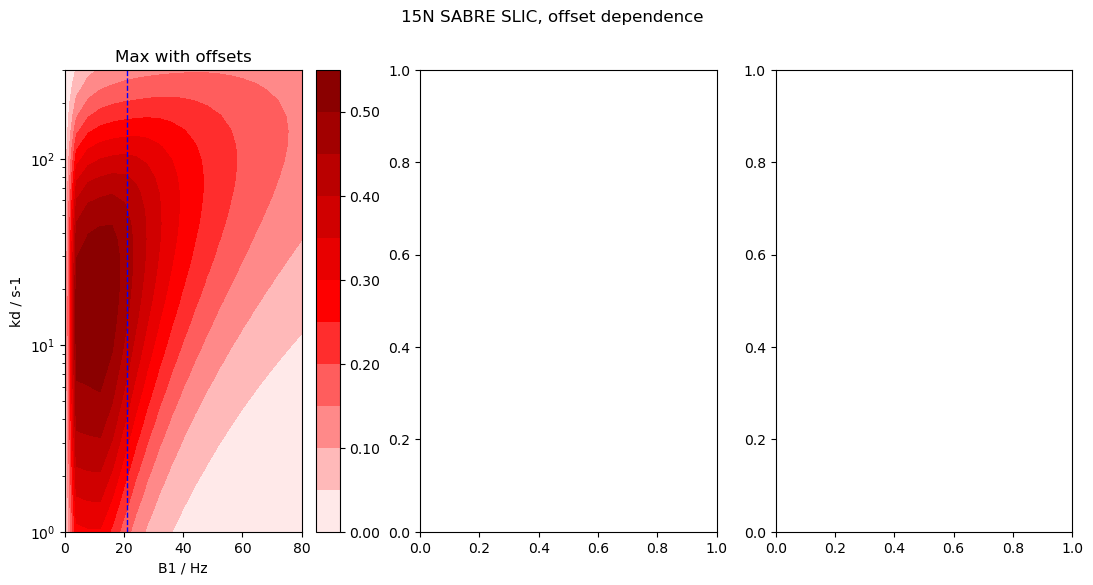

In [ ]:
B1sv, kdsv = np.meshgrid(B1s, kds, indexing="ij")
fig, axs = plt.subplots(1, 3, figsize=(13, 6))

fig.suptitle('15N SABRE SLIC, offset dependence')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]
ax3 = axs[2]

cs1 = ax1.contourf(
    B1sv, kdsv, 
    P_SLIC_abs_offset, 
    levels=10, cmap=my_cmap, 
    norm=CenteredNorm()
)
ax1.axvline(21, color='blue', lw=1, linestyle='--')
ax1.set_xlabel(r'B1 / Hz')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Max with offsets')
fig.colorbar(cs1, ax=ax1, format='%.2f')


# #===# 
# cs2 = ax2.contourf(
#     B1sv, kdsv, 
#     P_2_SLIC_NS['free'], levels=10, 
#     cmap=my_cmap, norm=CenteredNorm()
# )
# ax2.set_xlabel(r'B1 / Hz')
# ax2.set_yscale('log')
# ax2.set_title('On ress')
# fig.colorbar(cs2, ax=ax2, format='%.2f')

# # ===# 
# cs3 = ax3.contourf(
#     B1sv, kdsv, 
#     P_SLIC_abs_offset - P_2_SLIC_NS['free'], 
#     levels=10, 
#     cmap=my_cmap, norm=CenteredNorm()
# )
# ax3.set_xlabel(r'B1 / Hz')
# ax3.set_yscale('log')
# ax3.set_title('Difference')
# fig.colorbar(cs3, ax=ax3, format='%.2f')

plt.show()

Finally, check all possible B1 on protons.

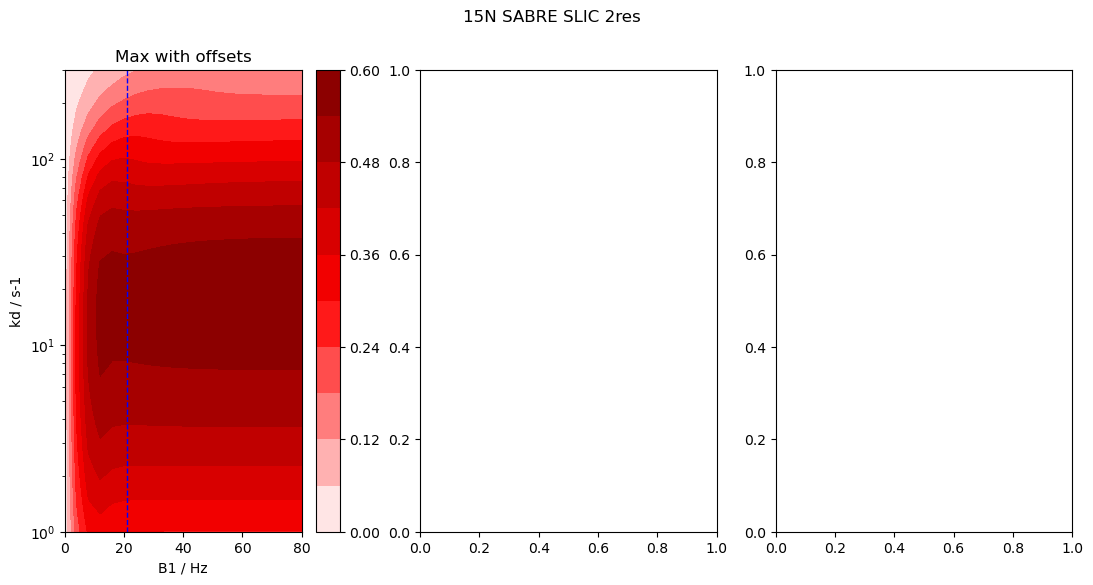

In [ ]:
B1sv, kdsv = np.meshgrid(B1s, kds, indexing="ij")
fig, axs = plt.subplots(1, 3, figsize=(13, 6))

fig.suptitle('15N SABRE SLIC 2res')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]
ax3 = axs[2]


cs1 = ax1.contourf(
    B1sv, kdsv, 
    P_SLIC_abs_B1H, 
    levels=10, cmap=my_cmap, 
    norm=CenteredNorm()
)
ax1.axvline(21, color='blue', lw=1, linestyle='--')
ax1.set_xlabel(r'B1 / Hz')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Max with offsets')
fig.colorbar(cs1, ax=ax1, format='%.2f')


# #===# 
# cs2 = ax2.contourf(
#     B1sv, kdsv, 
#     P_2_SLIC_NS['free'], levels=10, 
#     cmap=my_cmap, norm=CenteredNorm()
# )
# ax2.set_xlabel(r'B1 / Hz')
# ax2.set_yscale('log')
# ax2.set_title('On ress')
# fig.colorbar(cs2, ax=ax2, format='%.2f')

# #===# 
# cs3 = ax3.contourf(
#     B1sv, kdsv, 
#     P_SLIC_abs_B1H - P_2_SLIC_NS['free'], 
#     levels=10, 
#     cmap=my_cmap, norm=CenteredNorm()
# )
# ax3.set_xlabel(r'B1 / Hz')
# ax3.set_yscale('log')
# ax3.set_title('Difference')
# fig.colorbar(cs3, ax=ax3, format='%.2f')

plt.show()

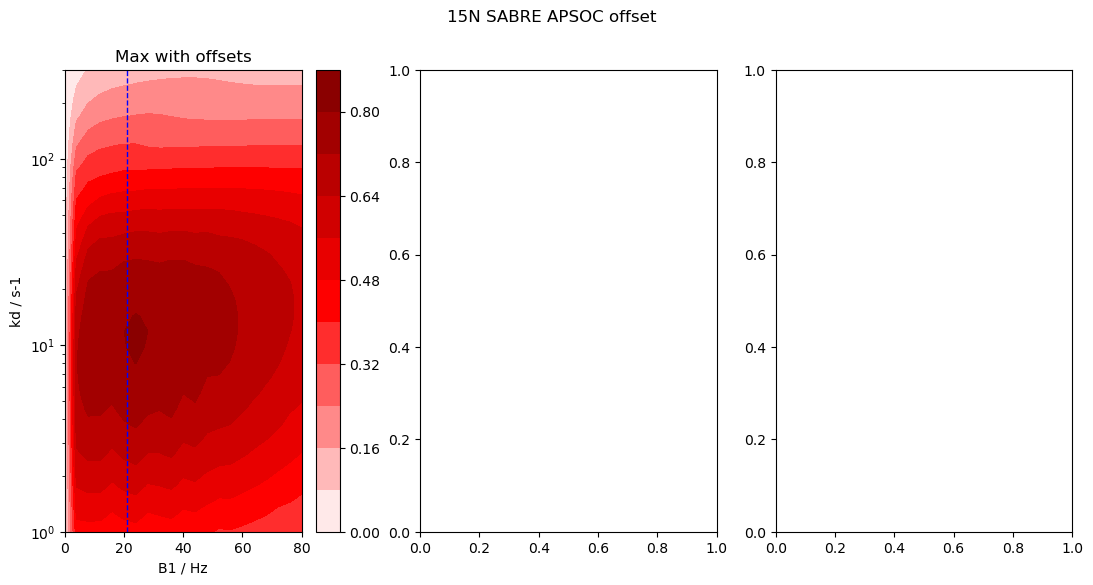

In [ ]:
B1sv, kdsv = np.meshgrid(B1s, kds, indexing="ij")
fig, axs = plt.subplots(1, 3, figsize=(13, 6))

fig.suptitle('15N SABRE APSOC offset')
my_cmap = 'seismic'

ax1 = axs[0]
ax2 = axs[1]
ax3 = axs[2]


cs1 = ax1.contourf(
    B1sv, kdsv, 
    P_SLIC_abs_max, 
    levels=10, cmap=my_cmap, 
    norm=CenteredNorm()
)
ax1.axvline(21, color='blue', lw=1, linestyle='--')
ax1.set_xlabel(r'B1 / Hz')
ax1.set_ylabel('kd / s-1')
ax1.set_yscale('log')
ax1.set_title('Max with offsets')
fig.colorbar(cs1, ax=ax1, format='%.2f')


# #===# 
# cs2 = ax2.contourf(
#     B1sv, kdsv, 
#     P_2_SLIC_NS['free'], levels=10, 
#     cmap=my_cmap, norm=CenteredNorm()
# )
# ax2.set_xlabel(r'B1 / Hz')
# ax2.set_yscale('log')
# ax2.set_title('On ress')
# fig.colorbar(cs2, ax=ax2, format='%.2f')

# #===# 
# cs3 = ax3.contourf(
#     B1sv, kdsv, 
#     P_SLIC_abs_max - P_2_SLIC_NS['free'], 
#     levels=10, 
#     cmap=my_cmap, norm=CenteredNorm()
# )
# ax3.set_xlabel(r'B1 / Hz')
# ax3.set_yscale('log')
# ax3.set_title('Difference')
# fig.colorbar(cs3, ax=ax3, format='%.2f')

plt.show()

In [ ]:
ind_max = np.unravel_index(
    np.abs(P_SLIC_abs).argmax(),  
    P_SLIC_abs.shape
) # b1_x, b1_h, b0_x, kd

kd_SLIC2r_max = kds[ind_max[3]]
b1_SLIC2r_max = B1s[ind_max[0]]
b1h_SLIC2r_max = B1sH[ind_max[1]]
b0_SLIC2r_max = offsets[ind_max[2]]

In [ ]:
print(
    'For APSOC-SABRE:',
    f'The best kd is {kd_SLIC2r_max:.2f} s*-1',
    f'With b1_n={b1_SLIC2r_max:.2f} Hz, b1_h={b1h_SLIC2r_max:.2f} Hz, offset = {b0_SLIC2r_max:.2f} Hz',
    sep='\n'
)

For APSOC-SABRE:
The best kd is 11.84 s*-1
With b1_n=24.00 Hz, b1_h=64.00 Hz, offset = 68.00 Hz


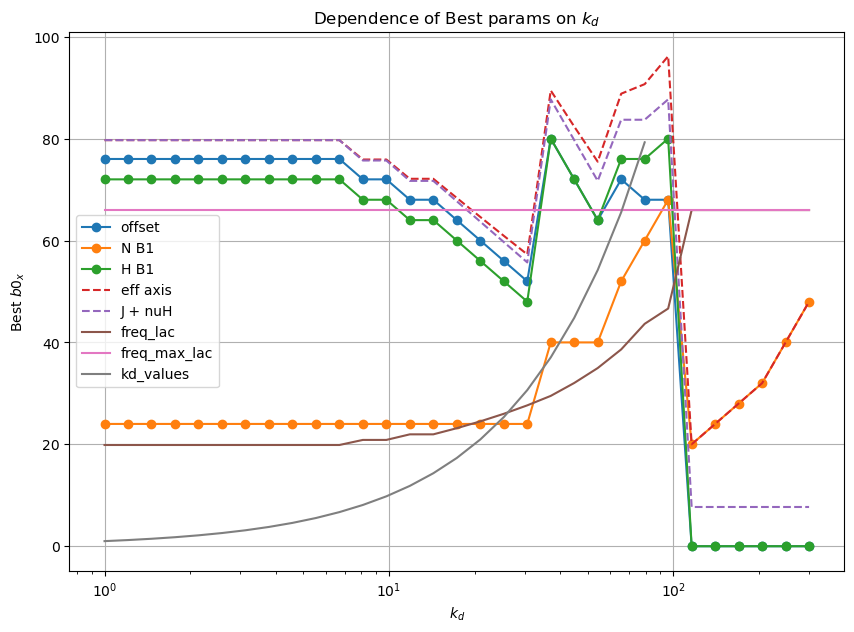

In [ ]:
# Reshape P_SLIC_abs to collapse (b1_x, b1_h, b0_x) into a single axis
flattened_shape = (np.prod(P_SLIC_abs.shape[:-1]), P_SLIC_abs.shape[-1])  # (flattened, kd)
P_SLIC_flat = P_SLIC_abs.reshape(flattened_shape)  # Reshape to 2D

# Find max index along the first axis (collapsed b1_x, b1_h, b0_x), separately for each k_d
ind_max_flat = np.abs(P_SLIC_flat).argmax(axis=0)  # 1D array of max indices (shape: (num_kd,))

# Convert flat indices back to multi-dimensional indices
ind_max = np.unravel_index(ind_max_flat, P_SLIC_abs.shape[:-1])  # Excluding kd axis

# Extract corresponding best b0_x values
b0_x_best = offsets[ind_max[2]]
b1_n_best = B1s[ind_max[0]]  
b1_h_best = B1sH[ind_max[1]]
kd_values = kds  # No need to change kds

nu_eff = np.sqrt(
    b1_n_best**2 + b0_x_best**2
)

J_plus_nuH = np.abs(b1_h_best) + np.abs(ss_C.Js[0, 1])


freq_lac = 2 * np.pi * ss_C.Js[0, 2] * b1_n_best / nu_eff / 2
freq_max_lac = 2 * np.pi * ss_C.Js[0, 2] * np.ones(len(nu_eff))  / 2
# Plot the results
plt.figure(figsize=(10, 7))
plt.plot(kd_values, np.abs(b0_x_best), 
         marker='o', linestyle='-', label='offset')
plt.plot(kd_values, np.abs(b1_n_best), 
         marker='o', linestyle='-', label='N B1')
plt.plot(kd_values, np.abs(b1_h_best), 
         marker='o', linestyle='-', label='H B1')

plt.plot(kd_values, nu_eff, linestyle='--', label='eff axis')
plt.plot(kd_values, J_plus_nuH, 
         linestyle='--', label='J + nuH')

plt.plot(kd_values, np.abs(freq_lac), label='freq_lac')
plt.plot(kd_values, np.abs(freq_max_lac), label='freq_max_lac')


plt.plot(kd_values[:24], kd_values[:24], label='kd_values')



plt.xlabel("$k_d$")
plt.xscale('log')
plt.ylabel("Best $b0_x$")
plt.title("Dependence of Best params on $k_d$")
plt.legend()
plt.grid(True)
plt.show()


It seems like it is really want to go to large delta across really large range of $k_d$

In [ ]:
kd_locs = np.geomspace(1, 300, 5)
b1_sv, b1h_sv = np.meshgrid(
    B1s, B1sH, indexing="ij")

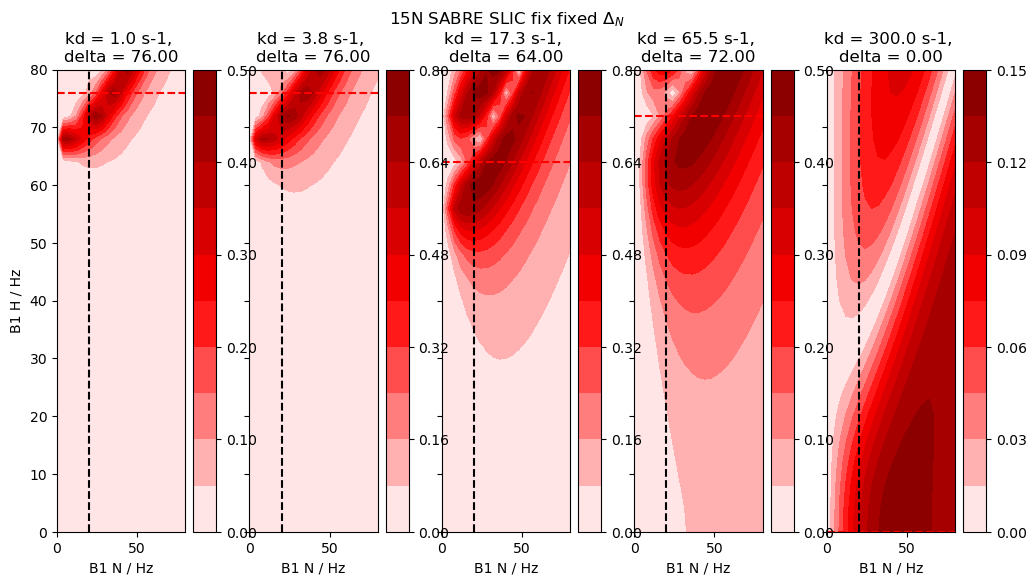

In [ ]:
fig, axs = plt.subplots(1, len(kd_locs), figsize=(12, 6), sharey=True)

fig.suptitle(r'15N SABRE SLIC fix fixed $\Delta_{N}$')
my_cmap = 'seismic'
n_levels = 10


# b1_x, b1_h, b0_x, kd
for idx, (kd_loc, ax) in enumerate(zip(kd_locs, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    idx_max = ind_max[2][idx_kd]
    # idx_max = 10
    # print(idx_max)
    cs = ax.contourf(
        b1_sv, b1h_sv, P_SLIC_abs[:, :, idx_max, idx_kd],
        # b1_sv, b1h_sv, P_2_SLIC_full['z'][:, :, idx_max, idx_kd],
        levels=n_levels, cmap=my_cmap, norm=CenteredNorm()
    )

    if idx == 0:
        ax.set_ylabel('B1 H / Hz')
    ax.set_xlabel('B1 N / Hz')
    offset_max = offsets[idx_max]
    ax.set_title(
        f'kd = {kds[idx_kd]:.1f} s-1, \ndelta = {offset_max:.2f}'
    )

    
    # ax.plot([0, 50], [0, 50], 'k--', lw=2)
    ax.axhline(offset_max, color='red', linestyle='--')  # Vertical line at x = 20
    ax.axvline(20, color='black', linestyle='--')  # Vertical line at x = 20
    if idx == len(kd_locs - 1):
        ax.legend()

    fig.colorbar(cs, ax=ax, format='%.2f')

plt.show()

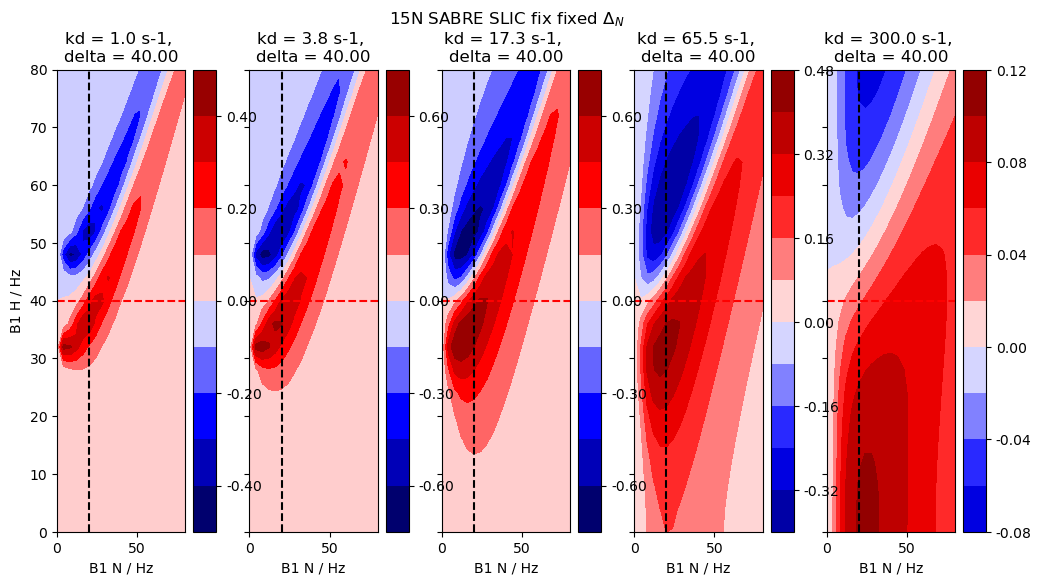

In [ ]:
fig, axs = plt.subplots(1, len(kd_locs), figsize=(12, 6), sharey=True)

fig.suptitle(r'15N SABRE SLIC fix fixed $\Delta_{N}$')
my_cmap = 'seismic'
n_levels = 10


# b1_x, b1_h, b0_x, kd
for idx, (kd_loc, ax) in enumerate(zip(kd_locs, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    # idx_max = ind_max[2][idx_kd]
    idx_max = 10
    # print(idx_max)
    cs = ax.contourf(
        # b1_sv, b1h_sv, P_SLIC_abs[:, :, idx_max, idx_kd],
        b1_sv, b1h_sv, P_2_SLIC_full['z'][:, :, idx_max, idx_kd],
        levels=n_levels, cmap=my_cmap, norm=CenteredNorm()
    )

    if idx == 0:
        ax.set_ylabel('B1 H / Hz')
    ax.set_xlabel('B1 N / Hz')
    offset_max = offsets[idx_max]
    ax.set_title(
        f'kd = {kds[idx_kd]:.1f} s-1, \ndelta = {offset_max:.2f}'
    )

    
    # ax.plot([0, 50], [0, 50], 'k--', lw=2)
    ax.axhline(offset_max, color='red', linestyle='--')  # Vertical line at x = 20
    ax.axvline(20, color='black', linestyle='--')  # Vertical line at x = 20
    if idx == len(kd_locs - 1):
        ax.legend()

    fig.colorbar(cs, ax=ax, format='%.2f')

plt.show()

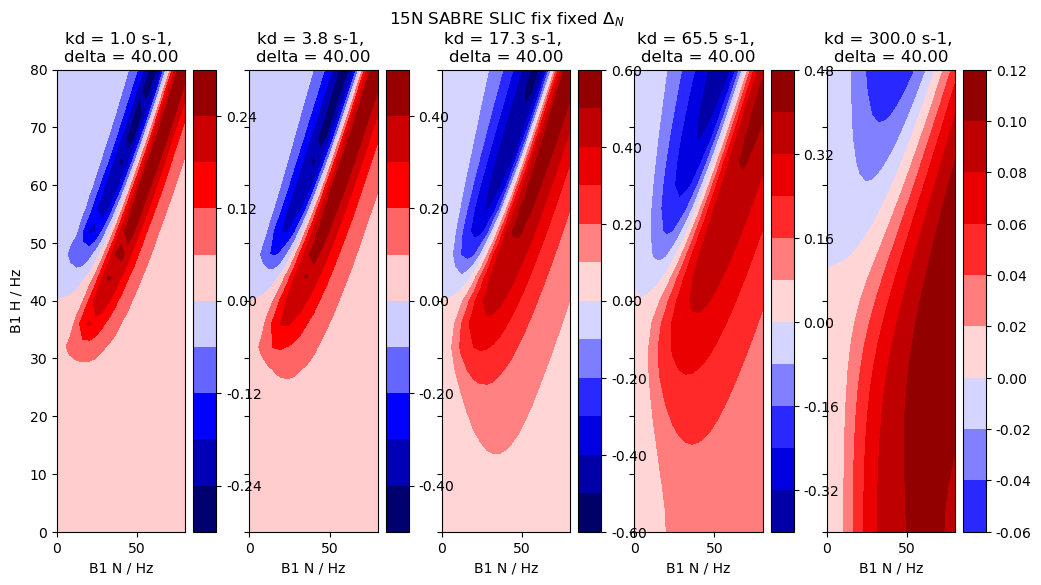

In [ ]:
fig, axs = plt.subplots(1, len(kd_locs), figsize=(12, 6), sharey=True)

fig.suptitle(r'15N SABRE SLIC fix fixed $\Delta_{N}$')
my_cmap = 'seismic'
n_levels = 10


# b1_x, b1_h, b0_x, kd
for idx, (kd_loc, ax) in enumerate(zip(kd_locs, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    # idx_max = ind_max[2][idx_kd]
    idx_max = 10
    # print(idx_max)
    cs = ax.contourf(
        # b1_sv, b1h_sv, P_SLIC_abs[:, :, idx_max, idx_kd],
        b1_sv, b1h_sv, P_2_SLIC_full['x'][:, :, idx_max, idx_kd],
        levels=n_levels, cmap=my_cmap, norm=CenteredNorm()
    )

    if idx == 0:
        ax.set_ylabel('B1 H / Hz')
    ax.set_xlabel('B1 N / Hz')
    ax.set_title(
        f'kd = {kds[idx_kd]:.1f} s-1, \ndelta = {offsets[idx_max]:.2f}'
    )

    
    # ax.plot([0, 50], [0, 50], 'k--', lw=2)
    
    if idx == len(kd_locs - 1):
        ax.legend()

    fig.colorbar(cs, ax=ax, format='%.2f')

plt.show()

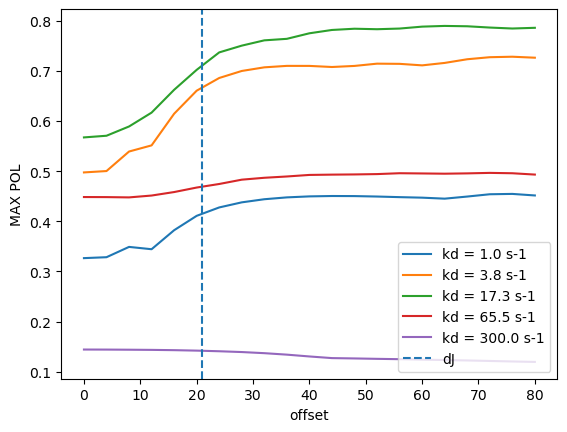

In [ ]:
for idx, kd_loc in enumerate(kd_locs):
    idx_kd = arg_nearest(kds, kd_loc)
    plt.plot(
        offsets, (P_SLIC_abs[:, :, :, idx_kd]).max(axis=(0, 1)),
        label=f'kd = {kds[idx_kd]:.1f} s-1'
    )
plt.axvline(np.abs(ss_C.Js[0, 2]), linestyle='dashed', label='dJ')
plt.legend()  
plt.ylabel('MAX POL')
plt.xlabel('offset')
plt.show()    

In [ ]:
b1_sv, offset_sv = np.meshgrid(
    B1s, offsets, indexing="ij")

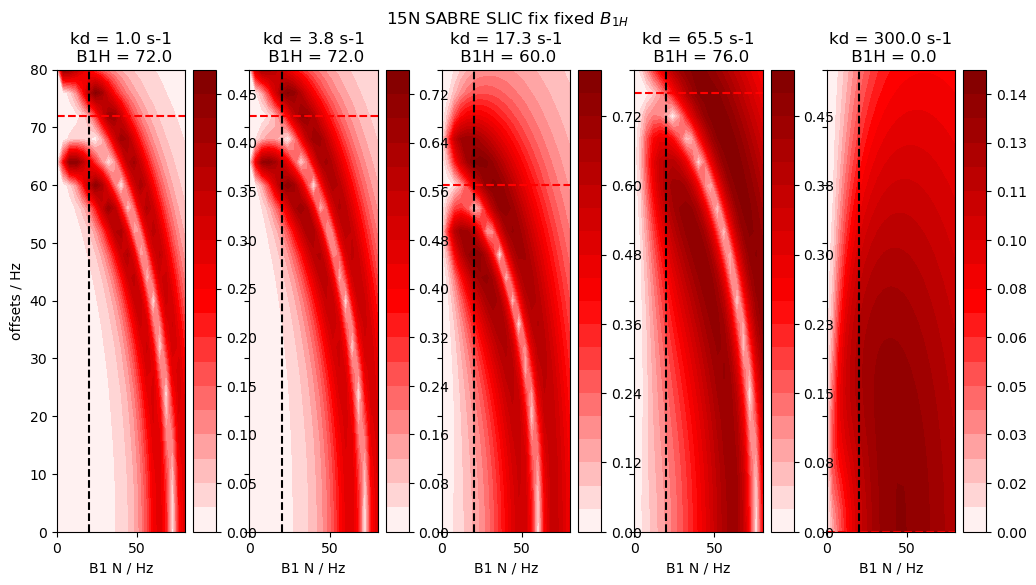

In [ ]:
fig, axs = plt.subplots(1, len(kd_locs), figsize=(12, 6), sharey=True)

fig.suptitle(r'15N SABRE SLIC fix fixed $B_{1H}$')
my_cmap = 'seismic'
n_levels = 20


# b1_x, b1_h, b0_x, kd
for idx, (kd_loc, ax) in enumerate(zip(kd_locs, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    idx_max = ind_max[1][idx_kd]
    # idx_max = 18
    cs = ax.contourf(
        b1_sv, offset_sv, P_SLIC_abs[:, idx_max, :, idx_kd],
        # b1_sv, offset_sv, P_2_SLIC_full['z'][:, idx_max, :, idx_kd],
        levels=n_levels, cmap=my_cmap, norm=CenteredNorm()
    )

    if idx == 0:
        ax.set_ylabel('offsets / Hz')
    ax.set_xlabel('B1 N / Hz')
    B1sH_max = B1sH[idx_max]
    ax.set_title(f'kd = {kds[idx_kd]:.1f} s-1\n B1H = {B1sH_max}')
    
    ax.axhline(B1sH_max, color='red', linestyle='--')  # Vertical line at x = 20
    ax.axvline(20, color='black', linestyle='--')  # Vertical line at x = 20
    
    if idx == len(kd_locs - 1):
        ax.legend()

    fig.colorbar(cs, ax=ax, format='%.2f')

plt.show()

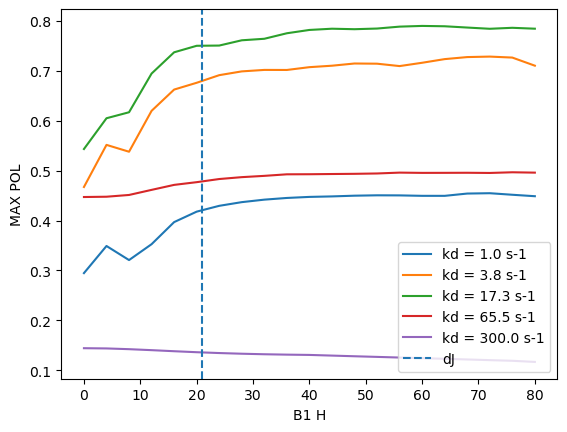

In [ ]:
for idx, kd_loc in enumerate(kd_locs):
    idx_kd = arg_nearest(kds, kd_loc)
    plt.plot(
        B1sH, (P_SLIC_abs[:, :, :, idx_kd]).max(axis=(0, 2)),
        label=f'kd = {kds[idx_kd]:.1f} s-1'
    )
plt.axvline(np.abs(ss_C.Js[0, 2]), linestyle='dashed', label='dJ')
plt.legend()  
plt.ylabel('MAX POL')
plt.xlabel('B1 H')
plt.show()    

In [ ]:
b1h_sv, offset_sv = np.meshgrid(
    B1sH, offsets, indexing="ij")

6
6
6
13
12


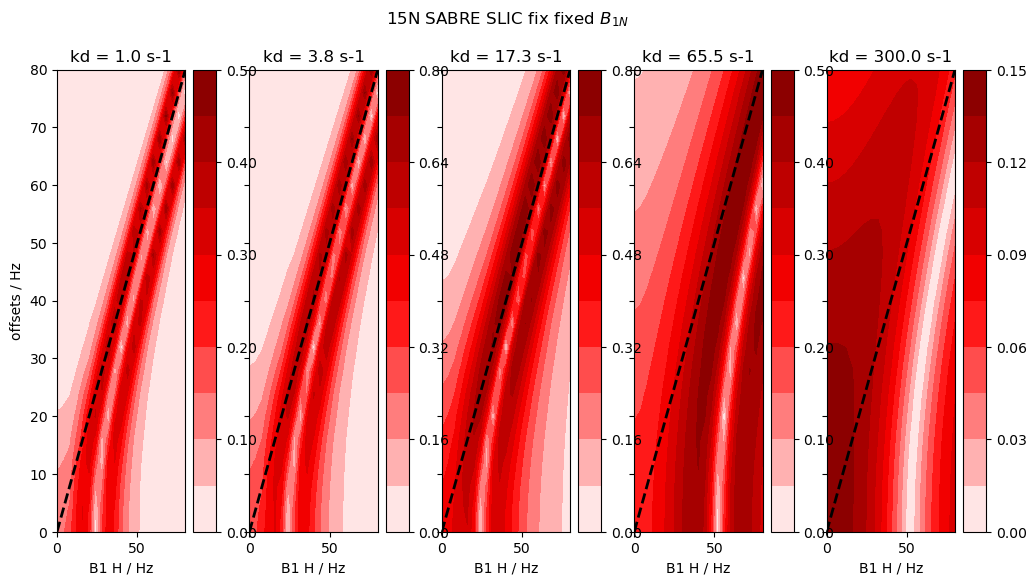

In [ ]:
fig, axs = plt.subplots(1, len(kd_locs), figsize=(12, 6), sharey=True)

fig.suptitle(r'15N SABRE SLIC fix fixed $B_{1N}$')
my_cmap = 'seismic'
n_levels = 10


# b1_x, b1_h, b0_x, kd
for idx, (kd_loc, ax) in enumerate(zip(kd_locs, axs)):
    idx_kd = arg_nearest(kds, kd_loc)
    idx_end = ind_max[0][idx_kd]
    # idx_end = 8
    print(idx_end)
    cs = ax.contourf(
        b1h_sv, offset_sv, P_SLIC_abs[idx_end, :, :, idx_kd],
        levels=n_levels, cmap=my_cmap, norm=CenteredNorm()
    )

    if idx == 0:
        ax.set_ylabel('offsets / Hz')
    ax.set_xlabel('B1 H / Hz')
    ax.set_title(f'kd = {kds[idx_kd]:.1f} s-1')
    
    ax.plot(
        [0, np.max(b1h_sv)], 
        [0, np.max(offset_sv)], 
        'k--', lw=2
    )

    if idx == len(kd_locs - 1):
        ax.legend()

    fig.colorbar(cs, ax=ax, format='%.2f')

plt.show()

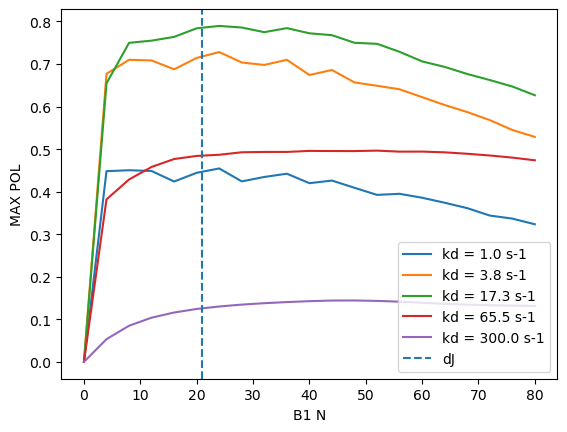

In [ ]:
for idx, kd_loc in enumerate(kd_locs):
    idx_kd = arg_nearest(kds, kd_loc)
    plt.plot(
        B1s, (P_SLIC_abs[:, :, :, idx_kd]).max(axis=(1, 2)),
        label=f'kd = {kds[idx_kd]:.1f} s-1'
    )
plt.axvline(np.abs(ss_C.Js[0, 2]), linestyle='dashed', label='dJ')
plt.legend()  
plt.ylabel('MAX POL')
plt.xlabel('B1 N')
plt.show()    

I think the dependency should be much less pronounced if we talk about the difference between offset and B1H.

Let's compare if ax where Polarization is build is correct.

And maybe overall difference for difference k_d.

In [ ]:
P_SLIC_abs_max.shape

(21, 31)

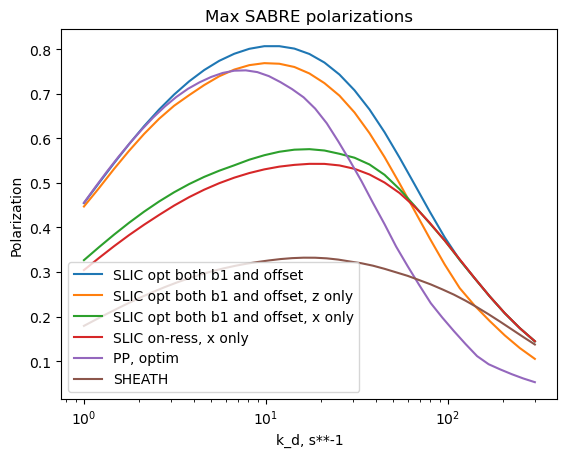

In [ ]:
kds = np.geomspace(1, 300, 31)
plt.plot(kds, P_SLIC_abs.max(axis=(0, 1, 2)), label='SLIC opt both b1 and offset')
plt.plot(
    kds, np.abs(P_2_SLIC_full['z']).max(axis=(0, 1, 2)), 
    label='SLIC opt both b1 and offset, z only'
)

plt.plot(
    kds, np.abs(P_2_SLIC_full['x']).max(axis=(0, 1, 2)), 
    label='SLIC opt both b1 and offset, x only'
)
# plt.plot(kds, P_SLIC_abs_B1H.max(axis=0), label='SLIC double-res, x-z')
# plt.plot(kds, P_SLIC_abs_offset.max(axis=0), label='SLIC res with offset, x-z')
plt.plot(kds, P_2_SLIC_NS['free'].max(axis=0), label='SLIC on-ress, x only')

kds_loc = np.geomspace(1, 300, 40)
plt.plot(kds_loc, np.abs(P_2_max['tau']).max(axis=0), label='PP, optim')
plt.plot(kds_loc, np.abs(np.abs(P_2_SHEATH['free'])).max(axis=0), label='SHEATH')
plt.title('Max SABRE polarizations')
plt.xlabel('k_d, s**-1')
plt.ylabel('Polarization')
plt.xscale('log')
plt.legend()
plt.show()

In [ ]:
from scipy.interpolate import interp1d

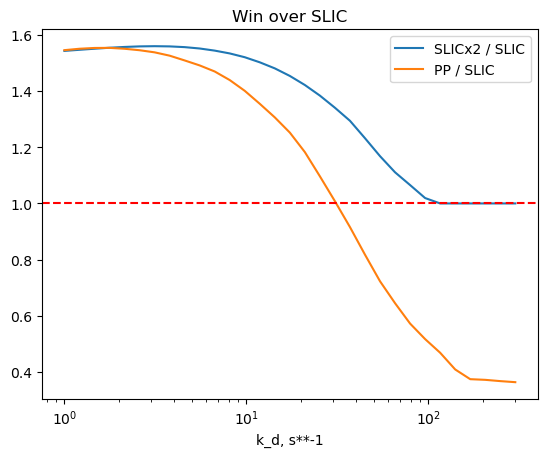

In [ ]:
kds = np.geomspace(1, 300, 31)
pol_2x_slic_max = P_SLIC_abs.max(axis=(0, 1, 2))
pol_slic_max = (P_SLIC_abs[:, 0, 0, :]).max(axis=(0))
kds_loc = np.geomspace(1, 300, 40)
interp_func = interp1d(kds_loc, np.abs(P_2_max['tau']).max(axis=0), kind='linear')
pol_pp_inter = interp_func(kds)


plt.plot(kds, pol_2x_slic_max / pol_slic_max, label='SLICx2 / SLIC')
plt.plot(
    kds, pol_pp_inter / pol_slic_max, 
    label='PP / SLIC'
)

plt.axhline(1, linestyle='dashed', color='red')
plt.title('Win over SLIC')
plt.xlabel('k_d, s**-1')
# plt.ylabel('Polarization')
plt.xscale('log')
plt.legend()
plt.show()

Let's see if tangent of polarization is the same.

Let's see if we generate polarization in general.

In [ ]:
P_overall = np.sqrt(P_2_SLIC_full['x']**2 + P_2_SLIC_full['z']**2)
mask = P_overall > 0.1
n_pol = mask.sum()
n_overall = np.prod(P_overall.shape)

print(f"Overall number of produced polarization {n_pol}")
print(f'Overall conditions {n_overall}')

Overall number of produced polarization 695275
Overall conditions 923521


In [ ]:
cos_pol = (
    P_2_SLIC_full['z'] / P_overall 
) # b1_n, b1_h, offset, kd
cos_field = offsets[None, :] / np.sqrt(B1s[:, None]**2 + offsets[None, :]**2)  # b1_n, offsets

C:\Users\BogdanRodin\AppData\Local\Temp\ipykernel_2596\553449772.py:4: RuntimeWarning: invalid value encountered in divide
  cos_field = offsets[None, :] / np.sqrt(B1s[:, None]**2 + offsets[None, :]**2)  # b1_n, offsets


In [ ]:
A = np.abs((np.abs(cos_pol) - np.abs(cos_field[:, None, :, None])))[mask]

In [ ]:
A[A > 0.01]

array([0.01951072, 0.01958477, 0.019684  , ..., 0.01014141, 0.01033849,
       0.01141834], shape=(15650,))

## PP

In [ ]:
kds = np.geomspace(1,300, 50)
phs = np.linspace(-3 * np.pi / 4, -np.pi / 2, 90)
tau_pps = np.array(
    [pulse_pol_params(7.7, phi=ph) for ph in phs]
)


P_2 = np.zeros([len(tau_pps),len(kds)])
obs = ss_S.pol_level(0)
sigma_0_pp = np.hstack([sigma_S, sigma_C])

In [ ]:
time_overall = 30
for i_tau, (tau_pp, ph) in enumerate(zip(tau_pps, phs)):
    for i_k, kd in enumerate(kds):
        #Set the magnetic field 
        uni_pp = PP_SABRE(
            tau_pp, ss_S, ss_C, kd, W, 
            nuc='15N', b0=B0_PP
        ).calc()
        # Here I suppress annoying outputs
        with HiddenPrints():
            sigma = null_space(sp.linalg.logm(uni_pp))
        sigma = sigma[:idx_S]
        sigma = vec2mat(sigma)

        #Normalize the steady-state density operator
        sigma = sigma / np.trace(sigma)

        P_2[i_tau, i_k] = np.real(amplitude(obs, sigma))

ValueError: cannot reshape array of size 0 into shape (2,2)

In [ ]:
tau_ppsv, kdsv = np.meshgrid(tau_pps, kds, indexing="ij")

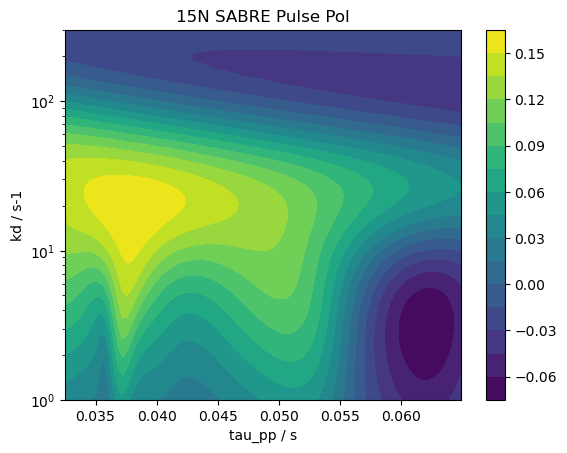

In [ ]:
cs = plt.contourf(tau_ppsv, kdsv, P_2, levels=20)
cbar = plt.colorbar(cs) 
plt.plot()
plt.xlabel('tau_pp / s')
plt.ylabel('kd / s-1')
plt.yscale('log')
plt.title('15N SABRE Pulse Pol')
plt.show()

Or we cah plot in phs

In [ ]:
tau_pps[P_2[:, arg_nearest(kds, 40)].argmax()] 

0.034291551145483726